# Вариант №14.

In [1]:
variant = 14

<a id="0"></a>

- 0. Импорты и определения
- 1. Описательные статистики  
  - 1.1. Выборочные характеристики  
  - 1.2. Группировка и гистограммы частот  

- 2. Интервальные оценки  
  - 2.1. Доверительные интервалы для математического ожидания  
  - 2.2. Доверительные интервалы для дисперсии  
  - 2.3. Доверительные интервалы для разности математических ожиданий  
  - 2.4. Доверительные интервалы для отношения дисперсий  

- 3. Проверка статистических гипотез о математических ожиданиях и дисперсиях  
  - 3.1. Проверка статистических гипотез о математических ожиданиях  
  - 3.2. Проверка статистических гипотез о дисперсиях  
  - 3.3. Проверка статистических гипотез о равенстве математических ожиданий  
  - 3.4. Проверка статистических гипотез о равенстве дисперсий  

- 4. Критерии согласия  
  - 4.1. Критерий χ²  
  - 4.2. Критерий Харке–Бера  

- 5. Проверка однородности выборок  
  - 5.1. Критерий знаков  
  - 5.2. Критерий χ²  

- 6. Таблицы сопряжённости  

- 7. Дисперсионный анализ  

- 8. Корреляционный анализ  
  - 8.1. Расчёт парных коэффициентов корреляции  
  - 8.2. Расчёт множественных коэффициентов корреляции  

- 9. Регрессионный анализ  
  - 9.1. Простейшая линейная регрессионная модель  
  - 9.2. Линейная регрессионная модель общего вида  
  - 9.3. Множественная линейная регрессионная модель  
  - 9.4. Выводы  


# Импорты и определения

### Библиотеки и их настройка

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import math as m
import statsmodels.api as sm
from IPython.display import display, Markdown  # для вывода формул в консоль

In [3]:
def mprint(*strings):  # функция вывода маркдаун в консоль
    for s in strings:
        display(Markdown(s))


def dataframe_to_markdown(df):
    if df.index.name is None:
        first_cell = "Index"
    elif df.columns.name is None:
        first_cell = df.index.name
    else:
        first_cell = df.index.name + "\\" + df.columns.name
    markdown_table = "| " + first_cell + " | " + " | ".join(df.columns) + " |\n"
    markdown_table += "|---" * (len(df.columns) + 1) + "|\n"  # Учитываем индекс

    for index, row in df.iterrows():
        row_values = [str(round(val, 2) if type(val) != str else val) for val in row]
        markdown_table += f"| {index} | " + " | ".join(row_values) + " |\n"

    return markdown_table


# можно выводить latex в надписях matplotlib
plt.rc("text", usetex=True)
plt.rc(
    "text.latex",
    preamble=r"""
\usepackage[english, russian]{babel}
\usepackage[utf8]{inputenc}
""",
)
plt.style.use("seaborn-v0_8")

### Парсинг вариантов

In [ ]:
# ??????? ?????????? ???????? ?????????????
# (?????? ??????? ????? ??????????? ?? GitHub)


<a id="parse"></a>

In [5]:
path_to_vars = ("C:/Users/79165/Downloads/var_matstat_K5.xls")
path_to_data = ("C:/Users/79165/Downloads/data_matstat_K5.xls")


In [6]:

datas = pd.read_excel(path_to_vars, index_col=0).loc[variant]

datas.head()

1.1         B16 B17 B18
1.2                 B16
2.1, 3.1            B16
2.2, 3.2            B16
2.3, 3.3        B16 B17
Name: 14, dtype: object

In [7]:
# создаём словарик: задание -> список столбцов
variant_dict = dict()
for tasks in datas.index:
    for task in tasks.split(", "):
        variant_dict[task] = (
            datas[tasks]
            .replace("А", "A")
            .replace("В", "B")
            .replace("С", "C")
            .split(" ")
        )

print(variant_dict)

{'1.1': ['B16', 'B17', 'B18'], '1.2': ['B16'], '2.1': ['B16'], '3.1': ['B16'], '2.2': ['B16'], '3.2': ['B16'], '2.3': ['B16', 'B17'], '3.3': ['B16', 'B17'], '2.4': ['B16', 'B17'], '3.4': ['B16', 'B17'], '4': ['B16'], '5': ['B16', 'B17'], '6': ['B3', 'B5'], '7': ['B3', 'B16'], '8.1': ['B16', 'B17'], '8.2': ['B16', 'B17', 'B18'], '9.1': ['B16', 'B2'], '9.2': ['B16', 'B2'], '9.3': ['B16', 'B7', 'B2']}


In [8]:
dfs = pd.read_excel(path_to_data, sheet_name=None)
dfs.keys()

dict_keys(['description', 'A - aaup', 'B - bodyfat', 'C - plasma', 'D - homedat'])

In [9]:
# создаём словарик: буква -> название листа в excel
sheet_dict = dict()
for value in list(dfs.keys())[1:]:
    key = value[0]
    sheet_dict[key] = value
print(sheet_dict)

{'A': 'A - aaup', 'B': 'B - bodyfat', 'C': 'C - plasma', 'D': 'D - homedat'}


In [10]:
# функция: задание -> необходимые данные
def data(task):
    X = []
    for data in variant_dict[task]:
        sheet = data[0]
        column = data
        df = dfs[sheet_dict[sheet]][column]
        X.append(df)
    return X

### Дополнительные функции

In [11]:
def verdict(alpha, p_value):
    if alpha > p_value:
        return "$H_0$ отклоняется"
    else:
        return "$H_0$ принимается"

<a id="1"></a>

# Раздел 1. Описательные статистики

<a id="11"></a>

## 1.1 Выборочные характеристики

### Условие

Анализируемый признак 1 – `B16` (Biceps circumference (cm))

Анализируемый признак 2 – `B17` (Forearm circumference (cm))

Анализируемый признак 3 – `B18` (Wrist circumference (cm))

### Определения

In [12]:
columns = data("1.1")
for i in columns:
    print(i.head())

0    32.0
1    30.5
2    28.8
3    32.4
4    32.2
Name: B16, dtype: float64
0    27.4
1    28.9
2    25.2
3    29.4
4    27.7
Name: B17, dtype: float64
0    17.1
1    18.2
2    16.6
3    18.2
4    17.7
Name: B18, dtype: float64


### Привести формулы расчёта выборочных характеристик

| Выборочная характеристика                | Формула расчёта                                                                                                                                                                                                                                 |
| ---------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Объём выборки                            | $n$                                                                                                                                                                                                                                             |
| Среднее                                  | $\overline x = \dfrac{1}{n} \sum\limits_{i = 1}^{n} x_i$                                                                                                                                                                                        |
| Выборочная дисперсия                     | $D_X^* = \dfrac{1}{n} \sum\limits_{i = 1}^{n} \left(x_i - \overline x\right)^2$                                                                                                                                                                 |
| Выборочное среднеквадратичное отклонение | $\sigma_X^* = \sqrt{D_X^*} =\sqrt{\dfrac{1}{n} \sum\limits_{i = 1}^{n} \left(x_i - \overline x\right)^2}$                                                                                                                                       |
| Выборочный коэффициент асимметрии        | $\gamma_X^* = \dfrac{\mu_{3,X}^*}{\left(\sigma_X^*\right)^3} = \dfrac{\dfrac{1}{n} \sum\limits_{i = 1}^{n} \left(x_i - \overline x\right)^3}{\left(\dfrac{1}{n} \sum\limits_{i = 1}^{n} \left(x_i - \overline x\right)^2\right)^{\frac{3}{2}}}$ |
| Выборочный эксцесс                       |      $\varepsilon_X^* = \dfrac{\mu_{4,X}^*}{\left(\sigma_X^*\right)^4} - 3 = \dfrac{\dfrac{1}{n} \sum\limits_{i = 1}^{n} \left(x_i - \overline x\right)^4}{\left(\dfrac{1}{n} \sum\limits_{i = 1}^{n} \left(x_i - \overline x\right)^2\right)^2} - 3$                                                                                                                                                                                                                                           |


### Рассчитать выборочные характеристики

`pd.skew()` возвращает несмещенный выборочный коэффициент асимметрии, поэтому лучше использовать `stats.skew(bias=True)`, чтобы его получить.

То же самое касается функции `kurtosis()`.

In [13]:
for i, X in enumerate(columns, start=1):
    mean_ = X.mean()
    D = X.var(ddof=0)
    d = X.std(ddof=0)
    g = stats.skew(X,bias = True)
    e = stats.kurtosis(X,bias = True)
    output = f"$\\mathbf{{X_{i}}}:$ \
        $\\overline x_{i} =$ {mean_:.2f}; \
        $D^*_{{X_{i}}} =$ {D:.2f}; \
        $\\sigma^*_{{X_{i}}} =$ {d:.2f}; \
        $\\gamma^*_{{X_{i}}} =$ {g:.2f}; \
        $\\varepsilon^*_{{X_{i}}} =$ {e:.2f} \
        "
    mprint(output)

$\mathbf{X_1}:$         $\overline x_1 =$ 32.27;         $D^*_{X_1} =$ 9.09;         $\sigma^*_{X_1} =$ 3.02;         $\gamma^*_{X_1} =$ 0.28;         $\varepsilon^*_{X_1} =$ 0.46         

$\mathbf{X_2}:$         $\overline x_2 =$ 28.66;         $D^*_{X_2} =$ 4.07;         $\sigma^*_{X_2} =$ 2.02;         $\gamma^*_{X_2} =$ -0.22;         $\varepsilon^*_{X_2} =$ 0.83         

$\mathbf{X_3}:$         $\overline x_3 =$ 18.23;         $D^*_{X_3} =$ 0.87;         $\sigma^*_{X_3} =$ 0.93;         $\gamma^*_{X_3} =$ 0.28;         $\varepsilon^*_{X_3} =$ 0.36         

<a id="12"></a>

## 1.2 Группировка и гистограммы частот

### Условие

Анализируемый признак – `B16`  	(Biceps circumference (cm))

Объём выборки – $n$ = `252`

### Определения

In [14]:
X = data("1.2")[0]
X

0      32.0
1      30.5
2      28.8
3      32.4
4      32.2
       ... 
247    25.6
248    35.2
249    31.3
250    30.5
251    33.7
Name: B16, Length: 252, dtype: float64

In [15]:
print(n := len(X))

252


In [16]:
X = pd.DataFrame(X.values, columns = ["value"])
X.head()

,value
0,32.0
1,30.5
2,28.8
3,32.4
4,32.2


Классическая формула Стерджесса:

$$k = 1 + 1.3*\log_2(n)$$


### Выбрать число групп

In [21]:
maximum = max(X["value"])
minimum = min(X["value"])
k = round(1 + 1.44 * m.log(n))
mprint(f"$\\mathbf{{X}}: \\max = {maximum}, \\min = {minimum}, n = {n}, k = {k}$")

$\mathbf{X}: \max = 45.0, \min = 24.8, n = 252, k = 9$

In [20]:
X["group"] = pd.cut(X["value"], bins=k)
X.head()

,value,group
0,32.0,"(31.533, 33.778]"
1,30.5,"(29.289, 31.533]"
2,28.8,"(27.044, 29.289]"
3,32.4,"(31.533, 33.778]"
4,32.2,"(31.533, 33.778]"


###  `delta_min = np.min([...])`

Берётся **минимальная ширина интервала**.

То есть:

$$
\delta_{\min} = \min_i (\text{right}_i - \text{left}_i)
$$

---

###  `delta_max = np.max([...])`

Берётся **максимальная ширина интервала**.

То есть:

$$
\delta_{\max} = \max_i (\text{right}_i - \text{left}_i)
$$


In [22]:
delta_min = np.min(
    [interval.right - interval.left for interval in X["group"].cat.categories]
)


delta_max = np.max(
    [interval.right - interval.left for interval in X["group"].cat.categories]
)
mprint(f"Ширина интервалов: от {delta_min:.2f} до {delta_max:.2f}")

Ширина интервалов: от 2.24 до 2.26

### Построить таблицу частот

In [23]:
groups = pd.DataFrame(index=pd.Index(range(1, k + 1), name="Номер интервала"))
groups["low edge"] = [interval.left for interval in X["group"].cat.categories]
groups["high edge"] = [interval.right for interval in X["group"].cat.categories]
groups["frequency"] = X["group"].value_counts().sort_index().values
groups["relative frequency"] = groups["frequency"] / n
groups["cumulative frequency"] = groups["frequency"].cumsum()
groups["cumulative relative frequency"] = groups["cumulative frequency"] / n
groups

,low edge,high edge,frequency,relative frequency,cumulative frequency,cumulative relative frequency
Номер интервала,,,,,,
1,24.780,27.044,10,0.039683,10,0.039683
2,27.044,29.289,26,0.103175,36,0.142857
3,29.289,31.533,72,0.285714,108,0.428571
4,31.533,33.778,70,0.277778,178,0.706349
5,33.778,36.022,44,0.174603,222,0.880952
6,36.022,38.267,25,0.099206,247,0.980159
7,38.267,40.511,4,0.015873,251,0.996032
8,40.511,42.756,0,0.000000,251,0.996032
9,42.756,45.000,1,0.003968,252,1.000000


### Построить гистограммы частот и полигоны частот

In [24]:
bin_centers = (groups["low edge"] + groups["high edge"]) / 2
width = groups["high edge"] - groups["low edge"]


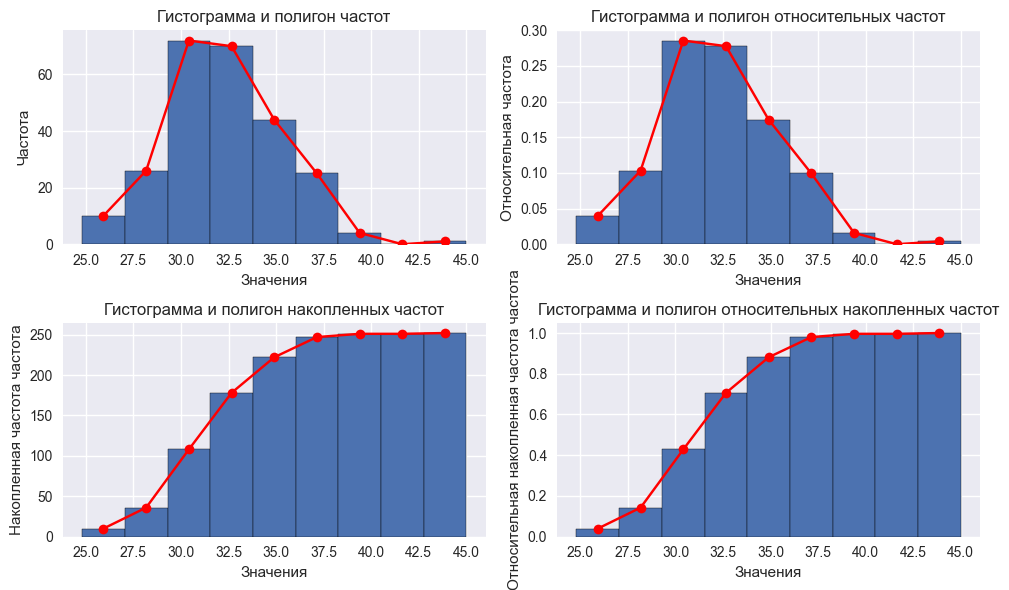

In [25]:
import matplotlib as mpl

mpl.rcParams['text.usetex'] = False  

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes[0, 0].bar(
    bin_centers,
    groups["frequency"],
    width=width,
    edgecolor="black",
)
axes[0, 0].plot(bin_centers, groups["frequency"], marker="o", color="r")
axes[0, 0].set_xlabel("Значения")
axes[0, 0].set_ylabel("Частота")
axes[0, 0].set_title("Гистограмма и полигон частот")

axes[0, 1].bar(
    bin_centers,
    groups["relative frequency"],
    width=width,
    edgecolor="black",
)
axes[0, 1].plot(bin_centers, groups["relative frequency"], marker="o", color="r")
axes[0, 1].set_xlabel("Значения")
axes[0, 1].set_ylabel("Относительная частота")
axes[0, 1].set_title("Гистограмма и полигон относительных частот")

axes[1, 0].bar(
    bin_centers,
    groups["cumulative frequency"],
    width=width,
    edgecolor="black",
)
axes[1, 0].plot(bin_centers, groups["cumulative frequency"], marker="o", color="r")
axes[1, 0].set_xlabel("Значения")
axes[1, 0].set_ylabel("Накопленная частота частота")
axes[1, 0].set_title("Гистограмма и полигон накопленных частот")

axes[1, 1].bar(
    bin_centers,
    groups["cumulative relative frequency"],
    width=width,
    edgecolor="black",
)
axes[1, 1].plot(
    bin_centers, groups["cumulative relative frequency"], marker="o", color="r"
)
axes[1, 1].set_xlabel("Значения")
axes[1, 1].set_ylabel("Относительная накопленная частота частота")
axes[1, 1].set_title("Гистограмма и полигон относительных накопленных частот")

plt.tight_layout()
plt.show()

### Построить эмпирическую фукнцию распределения

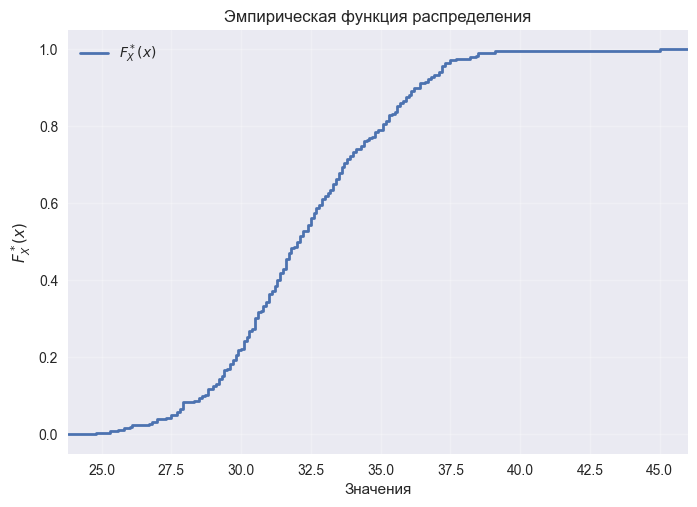

In [26]:


X_sorted = np.sort(X["value"].to_numpy())


spread = X_sorted[-1] - X_sorted[0]
pad = 0.05 * spread 

x_step = np.concatenate(([X_sorted[0] - pad],X_sorted,[X_sorted[-1] + pad],))
F = np.concatenate(([0],np.arange(1, n + 1) / n,[1],))

plt.step(x_step, F, where="post", label=r"$F_X^*(x)$", linewidth=2)
plt.xlim(x_step[0], x_step[-1])
plt.ylim(-0.05, 1.05)
plt.xlabel("Значения")
plt.ylabel(r"$F_X^*(x)$")
plt.title("Эмпирическая функция распределения")
plt.legend()
plt.grid(alpha=0.25)
plt.show()



<a id="2"></a>

# Раздел 2. Интервальные оценки

<a id="21"></a>

## 2.1 Доверительные интервалы для математического ожидания

### Условие

Анализируемый признак – `B16`  	Biceps circumference (cm)

Объём выборки – $n$ = `252`

Оцениваемый параметр – `m`

### Определения

In [192]:
X = data("2.1")[0]
X.head()

0    32.0
1    30.5
2    28.8
3    32.4
4    32.2
Name: B16, dtype: float64

In [193]:
print(n := len(X))

252


### Привести формулы расчёта доверительных интервалов

Так как у нас есть только выборка, мы не можем знать параметров генеральной совокупности(в том числе $m$ и $\sigma$), поэтому будем рассчитывать доверительные интервалы, используя данный факт. 

В данном случае `стьюдентизованное среднее` выступает в качестве центральной статистики:

| Граница доверительного интервала | Формула расчёта                                                                               |
| -------------------------------- | --------------------------------------------------------------------------------------------- |
| Нижняя граница                   | $\overline {\mathbf{X}} - \dfrac{S}{\sqrt{n}} \cdot t_{1-\frac{\alpha}{2}, \left(n-1\right)}$ |
| Верхняя граница                  | $\overline {\mathbf{X}} + \dfrac{S}{\sqrt{n}} \cdot t_{1-\frac{\alpha}{2}, \left(n-1\right)}$ |


### Рассчитать доверительные интервалы

In [194]:
intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)
alphas = [0.01, 0.05, 0.1]
std_err = stats.sem(X)
for alpha in alphas:
    intervals[f"$\\alpha =$ {alpha}"] = stats.t.interval(
        1 - alpha, df=n - 1, loc=X.mean(), scale=std_err
    )
intervals

,$\alpha =$ 0.01,$\alpha =$ 0.05,$\alpha =$ 0.1
Граница доверительного интервала,,,
Нижняя граница,31.779420,31.898580,31.959201
Верхняя граница,32.767405,32.648245,32.587625


<a id="22"></a>

## 2.2 Доверительные интервалы для дисперсии

### Условие

Анализируемый признак  – `B16` Biceps circumference (cm)

Объём выборки – $n$ = `252`

Оцениваемый параметр – $\sigma^2$

### Определения

In [195]:
X = data("2.2")[0]
X.head()

0    32.0
1    30.5
2    28.8
3    32.4
4    32.2
Name: B16, dtype: float64

In [196]:
print(n := len(X))

252


### Привести формулы расчёта доверительных интервалов

| Граница доверительного интервала | Формула расчёта                                                                               |
| -------------------------------- | --------------------------------------------------------------------------------------------- |
| Нижняя граница                   | $\dfrac{\left(n-1\right) \cdot S^2}{\chi^2_{1-\frac{\alpha}{2}, \left(n-1\right)}}$ |
| Верхняя граница                  | $\dfrac{\left(n-1\right) \cdot S^2}{\chi^2_{\frac{\alpha}{2}, \left(n-1\right)}}$ |


### Рассчитать доверительные интервалы

In [197]:
intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)
alphas = [0.01, 0.05, 0.1]
for alpha in alphas:
    chi2_upper, chi2_lower = stats.chi2.interval(1 - alpha, df=n - 1)
    intervals[f"$\\alpha =$ {alpha}"] = [
        (n - 1) * X.var(ddof=1) / chi2_lower,
        (n - 1) * X.var(ddof=1) / chi2_upper,
    ]
intervals

,$\alpha =$ 0.01,$\alpha =$ 0.05,$\alpha =$ 0.1
Граница доверительного интервала,,,
Нижняя граница,7.332595,7.720132,7.929094
Верхняя граница,11.627525,10.961915,10.640781


<a id="23"></a>

## 2.3 Доверительные интервалы для разности мат. ожиданий

### Условие

Анализируемый признак 1 – `B16` Biceps circumference (cm)

Анализируемый признак 2 – `B17` Forearm circumference (cm)

Объёмы выборок – $n_1 = n_2 = 252$

Оцениваемый параметр – $m_1 - m_2$

### Определения

In [198]:
X1, X2 = data("2.3")
X1.head(), X2.head()

(0    32.0
 1    30.5
 2    28.8
 3    32.4
 4    32.2
 Name: B16, dtype: float64,
 0    27.4
 1    28.9
 2    25.2
 3    29.4
 4    27.7
 Name: B17, dtype: float64)

In [199]:
print(n1 := len(X1), n2 := len(X2))

252 252


### Привести формулы расчёта доверительных интервалов

| Граница доверительного интервала | Формула расчёта                                                                                                                                                 |
| -------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Нижняя граница                   | $\left(\overline{\mathbf{X_1}} - \overline{\mathbf{X_2}}\right) - t_{1-\frac{\alpha}{2}, (n_1 + n_2 -2)} \cdot S \cdot \sqrt{\dfrac{1}{n_1} + \dfrac{1}{n_2}} $ |
| Верхняя граница                  | $\left(\overline{\mathbf{X_1}} - \overline{\mathbf{X_2}}\right) + t_{1-\frac{\alpha}{2}, (n_1 + n_2 -2)} \cdot S \cdot \sqrt{\dfrac{1}{n_1} + \dfrac{1}{n_2}} $ |
| $S$                              | $\sqrt{\dfrac{(n_1 - 1)S_1^2 + (n_2-1) S_2^2}{n_1 + n_2 -2}}  $                                                                                                 |


### Рассчитать доверительные интервалы

In [200]:
intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)
alphas = [0.01, 0.05, 0.1]
std_err = m.sqrt(
    ((n1 - 1) * X1.var(ddof=1) + (n2 - 1) * X2.var(ddof=1))
    / (n1 + n2 - 2)
    * (1 / n1 + 1 / n2)
)
for alpha in alphas:
    intervals[f"$\\alpha =$ {alpha}"] = stats.t.interval(
        1 - alpha, df=n1 + n2 - 2, loc=X1.mean() - X2.mean(), scale=std_err
    )
intervals

,$\alpha =$ 0.01,$\alpha =$ 0.05,$\alpha =$ 0.1
Граница доверительного интервала,,,
Нижняя граница,3.017494,3.159673,3.232211
Верхняя граница,4.201553,4.059375,3.986837


<a id="24"></a>

## 2.4. Доверительные интервалы для отношения дисперсий

### Условие

Анализируемый признак 1 – `B16` Biceps circumference (cm)

Анализируемый признак 2 – `B17` Forearm circumference (cm)

Объёмы выборок – $n_1 = n_2 = 252$

Оцениваемый параметр – $\dfrac{\sigma_1^2}{\sigma_2^2}$


### Определения

In [201]:
X1, X2 = data("2.4")
X1.head(), X2.head()

(0    32.0
 1    30.5
 2    28.8
 3    32.4
 4    32.2
 Name: B16, dtype: float64,
 0    27.4
 1    28.9
 2    25.2
 3    29.4
 4    27.7
 Name: B17, dtype: float64)

In [202]:
print(n1 := len(X1), n2 := len(X2))

252 252


### Привести формулы расчёта доверительных интервалов

| Граница доверительного интервала | Формула расчёта                                                       |
| -------------------------------- | --------------------------------------------------------------------- |
| Нижняя граница                   | $\dfrac{S_1^2}{S_2^2} \cdot F_{\frac{\alpha}{2}, (n_1-1, n_2-1)}$     |
| Верхняя граница                  | $\dfrac{S_1^2}{S_2^2} \cdot F_{1 - \frac{\alpha}{2}, (n_1-1, n_2-1)}$ |

### Рассчитать доверительные интервалы

In [203]:
intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)
alphas = [0.01, 0.05, 0.1]
for alpha in alphas:
    intervals[f"$\\alpha =$ {alpha}"] = stats.f.interval(
        1 - alpha, dfn=n1 - 1, dfd=n2 - 1, loc=0, scale=X1.var(ddof=1) / X2.var(ddof=1)
    )
intervals

,$\alpha =$ 0.01,$\alpha =$ 0.05,$\alpha =$ 0.1
Граница доверительного интервала,,,
Нижняя граница,1.613274,1.744541,1.815643
Верхняя граница,3.097793,2.864702,2.752518


<a id="3"></a>

# Раздел 3. Проверка статистических гипотез о математических ожиданиях и дисперсиях

<a id="31"></a>

## 3.1 Проверка статистических гипотез о математических ожиданиях

### Условие

Анализируемый признак  – `B16`  Biceps circumference (cm)

Объём выборки – $n$ = `252`

Статистическая гипотеза: $H_0:\ m = m_0; \quad H':\ m \neq m_0$

### Определения

In [204]:
X = data("3.1")[0]
X.head()

0    32.0
1    30.5
2    28.8
3    32.4
4    32.2
Name: B16, dtype: float64

In [205]:
print(n := len(X))

252


### Указать формулы расчёта показателей, используемых при проверке статистических гипотез

Мы не знаем параметр $\sigma$, значит используем `t-test`.

### Рассчитать показатели вариации, используемые в регрессионном анализе

|                                                                                  | Выражение                                                                |
| -------------------------------------------------------------------------------- | ------------------------------------------------------------------------ |
| Формула расчёта статистики критерия                                              | $Z = \dfrac{\overline X - m_0}{S/\sqrt{n}}$                              |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $T(n - 1)$                                                               |
| Формулы расчёта критических точек                                                | $\pm t_{1 - \frac{\alpha}{2}, n - 1}$                                    |
| Формула расчёта $p$-value                                                        | $2\min(F_Z(z_{\text{выб}} \mid H_0),\ 1 - F_Z(z_{\text{выб}} \mid H_0))$ |


### Выбрать произвольные значения $m_0$ и проверить статистические гипотезы

In [ ]:
alpha = 0.1
m0_list = [32, 50, 40]

mprint(r"### T-test")
for m0 in m0_list:
    z, p_value = stats.ttest_1samp(X, m0)
    mprint(
        r"---",
        f"$H_0: m = m_0 = {m0}$",
        f"$z_{{выб}} =$ {z:.2f}",
        f"$p =$ {p_value:.2f}",
        verdict(alpha, p_value),
    )


### T-test

---

$H_0: m = m_0 = 32$

$z_{выб} =$ 1.44

$p =$ 0.15

...

$H_0: m = m_0 = 40$

$z_{выб} =$ -40.60

$p =$ 0.00

$H_0$ отклоняется

32.2734126984127


<a id="32"></a>

## 3.2 Проверка статистических гипотез о дисперсиях

### Условие

Анализируемый признак  – `B16` Biceps circumference (cm)

Объём выборки – $n$ = `252`

Статистическая гипотеза: $H_0:\ \sigma = \sigma_0; \quad H':\ \sigma \neq \sigma_0$

### Определения

In [207]:
X = data("3.2")[0]
X.head()

0    32.0
1    30.5
2    28.8
3    32.4
4    32.2
Name: B16, dtype: float64

In [208]:
print(n := len(X))

252


### Указать формулы расчёта показателей, используемых при проверке статистических гипотез

Мы не знаем параметр $m$, значит используем $\chi^2-test$.

|                                                                                  | Выражение                                                                 |
| -------------------------------------------------------------------------------- | ------------------------------------------------------------------------- |
| Формула расчёта статистики критерия                                              | $Z = \dfrac{(n - 1)S^2}{\sigma_0^2}$                                      |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $\chi^2(n - 1)$                                                           |
| Формулы расчёта критических точек                                                | $\chi^2_{\frac{\alpha}{2}, n - 1},\ \chi^2_{1 - \frac{\alpha}{2}, n - 1}$ |
| Формула расчёта $p$-value                                                        | $2\min(F_Z(z_{\text{выб}} \mid H_0),\ 1 - F_Z(z_{\text{выб}} \mid H_0))$  |


### Выбрать произвольные значения $\sigma_0$ и проверить статистические гипотезы

In [209]:
def chisquare(X, value):
    n = len(X)
    z = (n - 1) * X.var(ddof=1) / value**2
    cdf = stats.chi2.cdf(z, df=n - 1)
    p_value = 2 * min(cdf, 1 - cdf)
    return z, p_value

In [422]:
alpha = 0.1
std0_list = [3, 30, 25]

mprint(r"### $\chi^2$-test")
for std0 in std0_list:
    z, p_value = chisquare(X, std0)
    mprint(
        r"---",
        f"$H_0: \\sigma = \\sigma_0 = {std0}$",
        f"$z_{{выб}} =$ {z:.2f}",
        f"$p =$ {p_value:.2f}",
        verdict(alpha, p_value),
    )

### $\chi^2$-test

---

$H_0: \sigma = \sigma_0 = 3$

$z_{выб} =$ 254.57

$p =$ 0.85

...

---

$H_0: \sigma = \sigma_0 = 25$

$z_{выб} =$ 3.67

$p =$ 0.00

$H_0$ отклоняется

<a id="33"></a>

## 3.3 Проверка статистических гипотез о равенстве математических ожиданий

### Условие

Анализируемый признак 1 – `B16` Biceps circumference (cm)

Анализируемый признак 2 – `B17` Forearm circumference (cm)

Объёмы выборок – $n_1 = n_2 = 252$

Статистическая гипотеза: $H_0:\ m_1 = m_2; \quad H':\ m_1 \neq m_2$

### Определения

In [211]:
X1, X2 = data("3.3")
X1.head(), X2.head()

(0    32.0
 1    30.5
 2    28.8
 3    32.4
 4    32.2
 Name: B16, dtype: float64,
 0    27.4
 1    28.9
 2    25.2
 3    29.4
 4    27.7
 Name: B17, dtype: float64)

In [212]:
print(n1 := len(X1), n2 := len(X2))

252 252


### Указать формулы расчёта показателей, используемых при проверке статистических гипотез

Мы не знаем параметр $\sigma$, значит используем `t-test`.

|                                                                                  | Выражение                                                                                                                                                  |
| -------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Формула расчёта статистики критерия                                              | $Z = \dfrac{\overline{X_1} - \overline{X_2}}{S\sqrt{\dfrac{1}{n_1} + \dfrac{1}{n_2}}}$, где $S^2 = \dfrac{(n_1 - 1)S_1^2 + (n_2 - 1)S_2^2}{n_1 + n_2 - 2}$ |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $T(n_1 + n_2 - 2)$                                                                                                                                         |
| Формулы расчёта критических точек                                                | $\pm t_{1 - \frac{\alpha}{2}, n_1 + n_2 - 2}$                                                                                                              |
| Формула расчёта $p$-value                                                        | $2\min(F_Z(z_{\text{выб}} \mid H_0),\ 1 - F_Z(z_{\text{выб}} \mid H_0))$                                                                                   |


### Проверить статистические гипотезы

In [213]:
alphas = [0.01, 0.05, 0.1]
z, p_value = stats.ttest_ind(X1, X2)
mprint(
    r"### two-sample T-test",
    f"$H_0: m_1 = m_2$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)
for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### two-sample T-test

$H_0: m_1 = m_2$

$z_{выб} =$ 15.76

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

<a id="34"></a>

## 3.4 Проверка статистических гипотез о равенстве дисперсий

### Условие

Анализируемый признак 1 – `B16`  Biceps circumference (cm)

Анализируемый признак 2 – `B17`  Forearm circumference (cm)

Объёмы выборок – $n_1 = n_2 = 252$

Статистическая гипотеза: $H_0:\ \sigma_1 = \sigma_2; \quad H':\ \sigma_1 \neq \sigma_2$

### Определения

In [214]:
X1, X2 = data("3.4")
X1.head(), X2.head()

(0    32.0
 1    30.5
 2    28.8
 3    32.4
 4    32.2
 Name: B16, dtype: float64,
 0    27.4
 1    28.9
 2    25.2
 3    29.4
 4    27.7
 Name: B17, dtype: float64)

In [215]:
print(n1 := len(X1), n2 := len(X2))

252 252


### Указать формулы расчёта показателей, используемых при проверке статистических гипотез

|                                                                                  | Выражение                                                                                 |
| -------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------- |
| Формула расчёта статистики критерия                                              | $Z = \dfrac{S_1^2}{S_2^2}$                                                                |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $F(n_1 - 1,\ n_2 - 1)$                                                                    |
| Формулы расчёта критических точек                                                | $F_{\frac{\alpha}{2},\ n_1 - 1,\ n_2 - 1},\ F_{1 - \frac{\alpha}{2},\ n_1 - 1,\ n_2 - 1}$ |
| Формула расчёта $p$-value                                                        | $2\min(F_Z(z_{\text{выб}} \mid H_0),\ 1 - F_Z(z_{\text{выб}} \mid H_0))$                  |

### Проверить статистические гипотезы

In [440]:
def Ftest(X1, X2):
    n1 = len(X1)
    n2 = len(X2)
    z = X1.var(ddof=1) / X2.var(ddof=1)
    cdf = stats.f.cdf(z, dfn=n1 - 1, dfd=n2 - 1)
    p_value = 2 * min(cdf, 1 - cdf)
    return z, p_value

In [441]:
alphas = [0.01, 0.05, 0.1]
z, p_value = Ftest(X1, X2)
mprint(
    r"### F-test",
    f"$H_0: \\sigma_1 = \\sigma_2$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### F-test

$H_0: \sigma_1 = \sigma_2$

$z_{выб} =$ 0.01

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

<a id="4"></a>

# Раздел 4. Критерии согласия

## Условие

Анализируемый признак  – `B16` Biceps circumference (cm)

Объём выборки – `252`

## Определения

In [218]:
X = data("4")[0]
X.head()

0    32.0
1    30.5
2    28.8
3    32.4
4    32.2
Name: B16, dtype: float64

In [219]:
print(n := len(X))

252


<a id="41"></a>

## 4.1 Критерий $\chi^2$ 

Теоретическое распределение - нормальное.

Статистическая гипотеза - $H_0:\ X \sim N; \quad H':\ X \nsim N$

### Указать формулы расчёта показателей, используемых при проверке статистических гипотез

|                                                                                  | Выражение                                                                         | Пояснение использованных обозначений                                                                                                                                                                                                                                                                                                                                               |
| -------------------------------------------------------------------------------- | --------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Формула расчёта статистики критерия                                              | $Z = \sum\limits_{i=1}^{k} \dfrac{\left(n_i - n \cdot p_i\right)^2}{n \cdot p_i}$ | $k$ - число интервалов в группированном статистическом ряду. $\\$ $n_i$ - частота попадания случайной величины $\mathbf X$ в интервал $\Delta_i$. $\\$ $p_i$ - вероятность попадания случайной величины $\mathbf X$ в интервал $\Delta_i$ в условиях $H_0$, то есть, если $\Delta_i = (a_{i-1}, a_{i}]$, то $$p_i = \int\limits_{a_{i-1}}^{a_{i}}g(x)dx = G(a_{i}) - G(a_{i-1}).$$ |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $\chi^2(k - r - 1)$                                                               | $r$ - количество оцениваемых параметров у предполагаемого распределения $G$.                                                                                                                                                                                                                                                                                                       |
| Формулы расчёта критической точки                                                | $\chi^2_{1 - \alpha,\ k - r - 1}$                                                 | Малые значения $Z$ нам также подходят, поэтому критическая область выбирается правосторонней                                                                                                                                                                                                                                                                                       |
| Формула расчёта $p$-value                                                        | $1 - F_Z(z_{\text{выб}} \mid H_0)$                                                |                                                                                                                                                                                                                                                                                                                                                                                    |

### Выбрать число групп

Область всевозможных значений предполагаемого распределения делят на $k$ групп(интервалов). Наше предполагаемое распределение - нормальное. Поэтому делим ВСЮ числовую прямую на $k$ интервалов.

выбираем число групп по формуле Стерджесса: $k \approx 1 + 1,3 \ln{n}$.

Однако критерий $\chi^2$ чувствителен к группам, для которых ожидаемые частоты $n \cdot p_i$ меньше 5. Поэтому при группировке нужно учитывать это.

1. Разбиваем выборку на $k$ групп библиотечными функциями.
2. Левый конец первого интервала и правый конец второго интервала устремляем в $\infty$.
3. Рассчитываем $n \cdot p_i$, и в зависимости от этого соединяем некоторые соседние интервалы.
4. Если нужно, подразбивал интервалы с большим $n \cdot p_i$.

In [450]:
k = round(1 + 1.3 * m.log(n))
k

8

In [451]:
frequences, bin_edges = np.histogram(X, bins=k)
bin_edges

array([24.8  , 27.325, 29.85 , 32.375, 34.9  , 37.425, 39.95 , 42.475,
       45.   ])

<a id="pm1000"></a>

Устремляю левый конец первого интервала в $-\infty$ и правый конец последнего интервала в $+\infty$. Можно считать, что точки $\pm1000$ - это $\pm\infty$, так как за интервал $(-1000, 1000)$, смотря по выборке, вероятность попадания ничтожно мала

In [452]:
bin_edges[0] = -1000
bin_edges[-1] = 1000
bin_edges

array([-1000.   ,    27.325,    29.85 ,    32.375,    34.9  ,    37.425,
          39.95 ,    42.475,  1000.   ])

Для каждого интервала $[a_{i-1}, a_i]$ найдём $p_i = G(a_i) - G(a_{i-1})$ - вероятность попадания случайной величины $\mathbf X$ в интервал $[a_{i-1}, a_i]$ в условиях $H_0$.



In [453]:
probabilities = np.diff(stats.norm(loc=X.mean(), scale=X.std(ddof=1)).cdf(bin_edges))
probabilities

array([0.05072582, 0.16051704, 0.30216864, 0.29426452, 0.1482365 ,
       0.03855822, 0.00516229, 0.00036696])

Мы нашли вероятности попасть в каждый интервал. Теперь найдём ожидаемые частоты $n \cdot p_i$.

In [454]:
def get_expected_frequencies(bin_edges, n, cdf=stats.norm.cdf):
    probabilities = np.diff(cdf(bin_edges))
    return n * probabilities

In [455]:
get_expected_frequencies(
    bin_edges, n, cdf=stats.norm(loc=X.mean(), scale=X.std(ddof=1)).cdf
)

array([12.78290698, 40.45029499, 76.14649783, 74.15465896, 37.35559794,
        9.71667184,  1.3008979 ,  0.09247357])

Как видим, для пятого и всех последующих интервалов ожидаемые частоты меньше 5. Условие $n \cdot p_i \gtrsim 5$ не выполняется.

Следует объединить эти интервалы с соседними, пока это условие не будет выполнено.

In [456]:
def merge_interval(bin_edges, expected_frequencies, i):
    # Объединяем два интервала в зависимости от их индексов.
    if i == 0:  # Крайний левый интервал
        bin_edges.pop(i + 1)
        expected_frequencies[i + 1] += expected_frequencies[i]
    elif i == len(bin_edges) - 2:  # Крайний правый интервал
        bin_edges.pop(i)
        expected_frequencies[i - 1] += expected_frequencies[i]
    else:  # Объединяем с соседом c наименьшим expected_frequencies
        if expected_frequencies[i - 1] < expected_frequencies[i + 1]:
            bin_edges.pop(i)
            expected_frequencies[i - 1] += expected_frequencies[i]
        else:
            bin_edges.pop(i + 1)
            expected_frequencies[i + 1] += expected_frequencies[i]
    expected_frequencies.pop(i)

In [457]:
def adjust_intervals(bin_edges, n, distrib=stats.norm, k=None):
    """
    Функция для корректировки интервалов и вероятностей

    Параметры:
    bin_edges: Границы интервалов
    n: uint - объем выборки
    distrib: распределение, которое мы хотим использовать для подсчета вероятностей
    k: uint
        Количество интервалов, которое мы хотим получить на выходе.
        Работает следующим образом:
        если None, то мы просто объединяем интервалы с малой ожидаемой частотой с соседними. На выходе получаем k <= len(intervals).
        если число, то мы сначала объединяем интервалы с малой ожидаемой частотой, получая k <= len(intervals),
        а затем разбиваем интервалы, для которых ожидаемая частота большая, таким образом получая на выходе k >= len(intervals).
    """
    cdf = distrib.cdf
    ppf = distrib.ppf
    expected_frequencies = get_expected_frequencies(bin_edges, n, cdf=cdf).tolist()
    if type(bin_edges) == np.ndarray:
        bin_edges = bin_edges.tolist()

    # Слияние интервалов с ожидаемой частотой <= 5
    i = 0
    while True:
        if expected_frequencies[i] <= 5:
            merge_interval(bin_edges, expected_frequencies, i)
            i -= 1

        i += 1
        if i >= len(bin_edges) - 1:
            break

    # Разбиение интервалов с максимальной ожидаемой частотой.
    if k is not None:
        while len(bin_edges) < k + 1:
            max_expected_frequency = max(expected_frequencies)

            # если максимальная ожидаемая частота меньше 10, то нельзя подразбивать интервалы
            if max_expected_frequency < 10:
                break

            max_index = expected_frequencies.index(max_expected_frequency)
            a, b = bin_edges[max_index : max_index + 2]

            # Находим такое c, что ожидаемая частота в интервалах (a, c) и (c, b) как минимум 5
            c = (ppf(cdf(a) + 5 / n) + ppf(cdf(b) - 5 / n)) / 2

            e_left, e_right = get_expected_frequencies([a, c, b], n, cdf=cdf)

            bin_edges.insert(max_index + 1, c)

            expected_frequencies[max_index] = e_left
            expected_frequencies.insert(max_index + 1, e_right)

    return np.array(bin_edges), np.array(expected_frequencies)

In [458]:
bin_edges, expected_frequencies = adjust_intervals(
    bin_edges, n, distrib=stats.norm(loc=X.mean(), scale=X.std(ddof=1)), k=8
)
bin_edges, expected_frequencies

(array([-1000.        ,    27.325     ,    29.85      ,    31.13832181,
           32.375     ,    33.60636845,    34.9       ,    37.425     ,
         1000.        ]),
 array([12.78290698, 40.45029499, 35.86648176, 40.28001607, 39.57679294,
        34.57786602, 37.35559794, 11.1100433 ]))

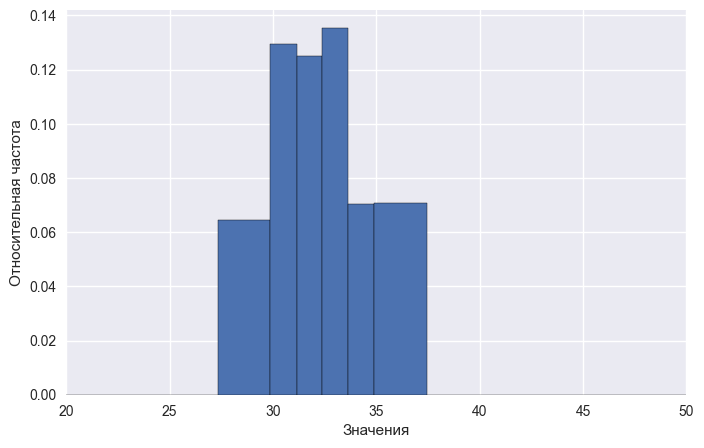

In [459]:
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
axes.hist(X, bins=bin_edges, edgecolor="black", density=True)
axes.set_xlabel("Значения")
axes.set_ylabel("Относительная частота")

plt.xlim(20,50)

plt.show()

Теперь мы чётко разбили всю числовую прямую на интервалы, для которых ожидаемые частоты $n \cdot p_i \gtrsim 5$.

In [460]:
mprint(
    f"Число интервалов: {k}",
    f"Ширина интервалов: от {np.diff(bin_edges).min():.2f} до {np.diff(bin_edges).max():.2f}",
)

Число интервалов: 8

Ширина интервалов: от 1.23 до 1027.33

### Построить таблицу частот

In [461]:
groups = pd.DataFrame(index=pd.Index(range(1, len(bin_edges)), name="Номер интервала"))
groups["low edge"] = bin_edges[:-1]
groups["high edge"] = bin_edges[1:]
groups["frequency"] = groups.apply(
    lambda row: ((X >= row["low edge"]) & (X < row["high edge"])).sum(), axis=1
)
groups["relative frequency"] = groups["frequency"] / n
groups["expected probability"] = expected_frequencies / n
groups

,low edge,high edge,frequency,relative frequency,expected probability
Номер интервала,,,,,
1,-1000.000000,27.325000,11,0.043651,0.050726
2,27.325000,29.850000,41,0.162698,0.160517
3,29.850000,31.138322,42,0.166667,0.142327
4,31.138322,32.375000,39,0.154762,0.159841
5,32.375000,33.606368,42,0.166667,0.157051
6,33.606368,34.900000,23,0.091270,0.137214
7,34.900000,37.425000,45,0.178571,0.148236
8,37.425000,1000.000000,9,0.035714,0.044087


### Построить гистограмму относительных частот и функцию плотности теоретического распределения на одном графике

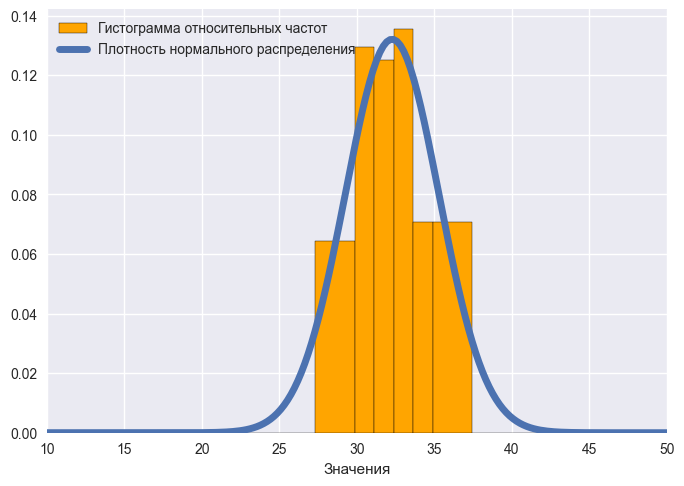

In [462]:
grid = np.linspace(X.min() - 100, X.max() + 100, 1000)
plt.hist(
    X,
    bins=bin_edges,
    edgecolor="black",
    density=True,
    label="Гистограмма относительных частот",
    color="orange",
)

plt.plot(
    grid,
    stats.norm.pdf(grid, loc=X.mean(), scale=X.std(ddof=1)),
    label="Плотность нормального распределения",
    lw=5,
)
plt.legend()
plt.xlim(10, 50)
plt.xlabel("Значения")
plt.show()

### Проверить статистические гипотезы

In [463]:
alphas = [0.01, 0.05, 0.1]

z, p_value = stats.chisquare(groups["frequency"], expected_frequencies, ddof=2)
mprint(
    r"### $\chi^2$-test",
    f"$H_0: F_X(x) = N(\\mu, \\sigma)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### $\chi^2$-test

$H_0: F_X(x) = N(\mu, \sigma)$

$z_{выб} =$ 7.34

$p =$ 0.20

При $\alpha = 0.01$ $H_0$ принимается

При $\alpha = 0.05$ $H_0$ принимается

При $\alpha = 0.1$ $H_0$ принимается

<a id="42"></a>

## 4.2 Критерий Харке-Бера

Статистическая гипотеза: $H_0:\ X \sim N; \quad H':\ X \nsim N$

Критерий Харке-Бера (Jarque-Bera) - это критерий проверки гипотезы о нормальности выборки:

$H_0:\ X \sim N; \quad H':\ X \nsim N$

Для проверки нормальности распределения нулевая гипотеза разбивается на две части:

$$H_0^{(1)}: \gamma_X = 0; \quad H'^{(1)}: \gamma_X \neq 0$$
$$H_0^{(2)}: \varepsilon_X = 0; \quad H'^{(2)}: \varepsilon_X \neq 0, где$$

$\gamma_X$ - коэффициент асимметрии, $\varepsilon_X$ - эксцесс.

Для этих гипотез используются следующие статистики:

$Z_1 = \dfrac{\gamma^*_X}{\sqrt{\dfrac{6}{n}}};\ \ \ Z_2 = \dfrac{\varepsilon^*_X}{\sqrt{\dfrac{24}{n}}}$, при этом $Z_1 \mid_{H_0^{(1)}} \sim N(0, 1);\ \ \ Z_2 \mid_{H_0^{(2)}} \sim N(0, 1)$.

Если хоть одна $H_0^{(1)}$ или $H_0^{(2)}$ отклоняется, то исходная гипотеза $H_0$ отклоняется.

Для проверки основной гипотезы строится общая статистика: $Z = Z_1^2 + Z_2^2$, при этом $Z \mid_{H_0} \sim \chi^2(2)$. Критическая область - правосторонняя.

### Указать формулы расчёта показателей, используемых при проверке статистических гипотез

|                                                                                  | Выражение                                                                                                                         | Пояснение использованных обозначений                                                                                                    |
| -------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| Формула расчёта статистики критерия                                              | $Z = Z^2_1 + Z^2_2$, где $\\Z_1 = \dfrac{\gamma^*_X}{\sqrt{\dfrac{6}{n}}};\\ Z_2 = \dfrac{\varepsilon^*_X}{\sqrt{\dfrac{24}{n}}}$ | $\gamma^*_X$ - выборочный коэффициент асимметрии, $\\ \varepsilon^*_X$ - выборочный эксцесс, $\\ n$ - объём выборки. |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $\chi^2(2)$                                                                                                                       |                                                                                                                                         |
| Формулы расчёта критической точки                                                | $\chi^2_{1 - \alpha,\ 2}$                                                                                                         | Правосторонняя критическая область.              |
| Формула расчёта $p$-value                                                        | $1 - F_Z(z_{\text{выб}} \mid H_0)$                                                                                                |                                                                                                                                         |

### Проверить статистические гипотезы

In [465]:
z, p_value = stats.jarque_bera(X)
mprint(
    r"### Jarque-Bera test",
    f"$H_0: F_X(x) = N(\\mu, \\sigma)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### Jarque-Bera test

$H_0: F_X(x) = N(\mu, \sigma)$

$z_{выб} =$ 5.65

$p =$ 0.06

При $\alpha = 0.01$ $H_0$ принимается

При $\alpha = 0.05$ $H_0$ принимается

При $\alpha = 0.1$ $H_0$ отклоняется

<a id="5"></a>

# Раздел 5. Проверка однородности выборок

## Условие

Анализируемый признак 1 – `B16`  Biceps circumference (cm)

Анализируемый признак 2 – `B17`  Forearm circumference (cm)

Объёмы выборок – $n_1 = n_2 = 252$

## Определения

In [244]:
X, Y = data("5")

X.head(), Y.head()

(0    32.0
 1    30.5
 2    28.8
 3    32.4
 4    32.2
 Name: B16, dtype: float64,
 0    27.4
 1    28.9
 2    25.2
 3    29.4
 4    27.7
 Name: B17, dtype: float64)

In [245]:
print(n1 := len(X), n2 := len(Y))

252 252


<a id="51"></a>

## 5.1 Критерий знаков

Статистическая гипотеза: $H_0:\ F_{X}(x) = F_{Y}(x); \quad H':\ F_{X}(x) \neq F_{Y}(x)$

### Указать формулы расчёта показателей, используемых при проверке статистических гипотез

|                                                                                  | Выражение                                                                                                                         | Пояснение использованных обозначений                                                                                                    |
| -------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| Формула расчёта статистики критерия                                              | $Z = \dfrac{K_+ - \dfrac{n}{2}}{\sqrt{\dfrac{n}{4}}}$ | $K_+$ - количество знаков `+` в выборке $z_1, \dots, z_n = x_1 - y_1, \dots, x_n - y_n$ |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $N(0, 1)$                                                                                                                       |                                                                                                                                         |
| Формулы расчёта критической точки                                                | $\pm u_{1 - \frac{\alpha}{2}}$                                                                                                         | Двусторонняя критическая область.              |
| Формула расчёта $p$-value                                                        | $2\min(F_Z(z_{\text{выб}} \mid H_0),\ 1 - F_Z(z_{\text{выб}} \mid H_0))$                                                                                                |                                                                                                                                         |


### Проверить статистические гипотезы

In [70]:
def sign_test(X, Y):
    if len(X) != len(Y):
        raise ValueError("Длины выборок должны совпадать")
    n = len(X)
    k = sum(X > Y)
    z = (k - n / 2) / m.sqrt(n / 4)
    p_value = 2 * min(stats.norm.cdf(z), 1 - stats.norm.cdf(z))
    return z, p_value

In [246]:
alphas = [0.01, 0.05, 0.1]

z, p_value = sign_test(X, Y)
mprint(
    r"### Sign test",
    f"$H_0: F_X(x) = F_Y(x)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### Sign test

$H_0: F_X(x) = F_Y(x)$

$z_{выб} =$ 15.24

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

<a id="52"></a>

## 5.2 Критерий $\chi^2$

Статистическая гипотеза: $H_0:\ F_{X}(x) = F_{Y}(x); \quad H':\ F_{X}(x) \neq F_{Y}(x)$

### Указать формулы расчёта показателей, используемых при проверке статистических гипотез

|                                                                                  | Выражение                                                                                                                         | Пояснение использованных обозначений                                                                                                    |
| -------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| Формула расчёта статистики критерия                                              | $Z = nm\sum\limits_{i=1}^{k}\dfrac{1}{n_i+m_i}\left(\dfrac{n_i}{n} - \dfrac{m_i}{m}\right)^2$ | $k$ - число интервалов в группированном статистическом ряду. $\\$ $n_i$ - частота попадания случайной величины $\mathbf X$ в интервал $\Delta_i$. $\\$ $m_i$ - частота попадания случайной величины $\mathbf X$ в интервал $\Delta_i$. $\\$ $n$ - объём выборки $x_1, \dots, x_n$ $\\$ $m$ - объём выборки $y_1, \dots, y_m$ |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $\chi^2(k - 1)$                                                                                                                       |                                                                                                                                         |
| Формулы расчёта критической точки                                                | $\chi^2_{1 - \alpha,\ k - 1}$                                                                                                         | Правосторонняя критическая область.              |
| Формула расчёта $p$-value                                                        | $1 - F_Z(z_{\text{выб}} \mid H_0)$                                                                                                |                                                                                                                                         |

### Выбрать число групп

Обычно выбирают число групп по формуле Стерджесса: $k \approx 1 + 1,3 \ln{\max(n, m)}$.

Однако критерий $\chi^2$ чувствителен к группам, для которых $n_i + m_i$ меньше 5. Поэтому при группировке нужно учитывать это.

Рассмотрим данный пример:

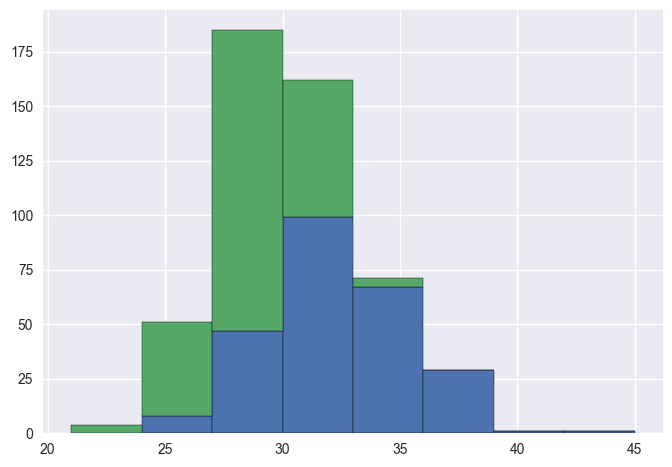

In [249]:
k = round(1 + 1.3 * m.log(max(n1, n2)))

frequences, bin_edges, _ = plt.hist((X, Y), bins=k, edgecolor="black", stacked=True)
plt.show()

Посмотрим на значения $n_i + m_i$ для каждого интервала.

In [251]:
frequences[1]

array([  4.,  51., 185., 162.,  71.,  29.,   1.,   1.])

Как видим, для последних трёх интервалов $n_i + m_i < 5$. Условие $n_i + m_i \gtrsim 5$ не выполняется.

Следует объединить эти интервалы с соседними, пока это условие не будет выполнено.

In [252]:
def merge_interval(bin_edges, frequences1, frequences2, i):
    
    
    if i == 0:  # Крайний левый интервал
        bin_edges.pop(i + 1)
        frequences1[i + 1] += frequences1[i]
        frequences2[i + 1] += frequences2[i]
        
    elif i == len(bin_edges) - 2:  # Крайний правый интервал
        bin_edges.pop(i)
        frequences1[i - 1] += frequences1[i]
        frequences2[i - 1] += frequences2[i]
        
    else:  # Объединяем с соседом c наименьшим expected_frequencies
        
        if (frequences1[i - 1] + frequences2[i - 1] < frequences1[i + 1] + frequences2[i + 1]):
            bin_edges.pop(i)
            frequences1[i - 1] += frequences1[i]
            frequences2[i - 1] += frequences2[i]
        else:
            bin_edges.pop(i + 1)
            frequences1[i + 1] += frequences1[i]
            frequences2[i + 1] += frequences2[i]
    frequences1.pop(i)
    frequences2.pop(i)

In [253]:
def adjust_intervals(bin_edges, X1, X2, k=None):
    """
    Функция для корректировки интервалов и частот попадания в них
    bin_edges: Границы интервалов
    X1: Первая выборка
    X2: Вторая выборка
    k: uint
        Количество интервалов, которое мы хотим получить на выходе.
        Работает следующим образом:
        если None, то мы просто объединяем интервалы с малой частотой попадания с соседними. На выходе получаем k <= len(intervals).
        если число, то мы сначала объединяем интервалы с малой частотой попадания, получая k <= len(intervals),
        а затем разбиваем интервалы, для которых частота попадания большая, таким образом получая на выходе k >= len(intervals).
    """
    frequences1, _ = np.histogram(X1, bins=bin_edges)
    frequences2, _ = np.histogram(X2, bins=bin_edges)
    frequences1 = frequences1.tolist()
    frequences2 = frequences2.tolist()

    # Слияние интервалов с малой частотой попадания
    i = 0
    while True:
        if frequences1[i] + frequences2[i] < 5:
            merge_interval(bin_edges, frequences1, frequences2, i)
            i -= 1

        i += 1
        if i >= len(bin_edges) - 1:
            break

    # Разбиение интервалов с максимальной частотой попадания
    if k is not None:
        while len(bin_edges) < k + 1:
            total_frequency = [x + y for x, y in zip(frequences1, frequences2)]
            max_frequency = max(total_frequency)

            # если максимальная частота меньше 5, то нельзя подразбивать интервалы
            if max_frequency < 10:
                break

            max_index = total_frequency.index(max_frequency)
            a, b = bin_edges[max_index : max_index + 2]

            # Находим такое c, что частота попадания в интервалах (a, c) и (c, b) как минимум 5
            c = (a + b) / 2

            frequences1[max_index] = ((X1 >= a) & (X1 < c)).sum()
            frequences2[max_index] = ((X2 >= a) & (X2 < c)).sum()
            frequences1.insert(max_index + 1, ((X1 >= c) & (X1 < b)).sum())
            frequences2.insert(max_index + 1, ((X2 >= c) & (X2 < b)).sum())
            bin_edges.insert(max_index + 1, c)

    return bin_edges, frequences1, frequences2

In [254]:
bin_edges, frequences1, frequences2 = adjust_intervals(bin_edges.tolist(), X, Y, k=k)
np.array(frequences1) + np.array(frequences2)

array([55, 82, 48, 55, 99, 63, 71, 31], dtype=int64)

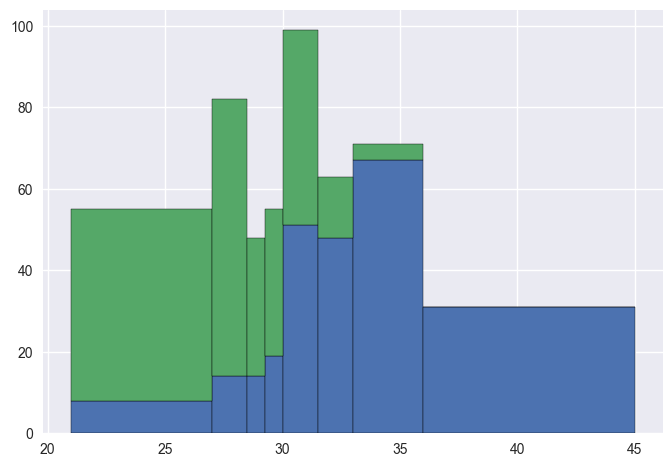

In [255]:
frequences, bin_edges, _ = plt.hist(
    (X, Y), bins=bin_edges, edgecolor="black", stacked=True
)
plt.show()

In [256]:
frequences[1]

array([55., 82., 48., 55., 99., 63., 71., 31.])

Теперь группировка выборок проведена правильно.

In [257]:
mprint(
    f"Число интервалов: {k}",
    f"Ширина интервалов: от {np.diff(bin_edges).min():.2f} до {np.diff(bin_edges).max():.2f}",
)

Число интервалов: 8

Ширина интервалов: от 0.75 до 9.00

### Построить таблицу частот

In [258]:
groups = pd.DataFrame(index=pd.Index(range(1, len(bin_edges)), name="Номер интервала"))
groups["low edge"] = bin_edges[:-1]
groups["high edge"] = bin_edges[1:]
groups["frequency1"] = frequences[0]
groups["frequency2"] = frequences[1] - frequences[0]
groups["relative frequency1"] = groups["frequency1"] / n1
groups["relative frequency2"] = groups["frequency2"] / n2

groups

,low edge,high edge,frequency1,frequency2,relative frequency1,relative frequency2
Номер интервала,,,,,,
1,21.00,27.00,8.0,47.0,0.031746,0.186508
2,27.00,28.50,14.0,68.0,0.055556,0.269841
3,28.50,29.25,14.0,34.0,0.055556,0.134921
4,29.25,30.00,19.0,36.0,0.075397,0.142857
5,30.00,31.50,51.0,48.0,0.202381,0.190476
6,31.50,33.00,48.0,15.0,0.190476,0.059524
7,33.00,36.00,67.0,4.0,0.265873,0.015873
8,36.00,45.00,31.0,0.0,0.123016,0.000000


### Построить гистограммы относительных частот на одном графике

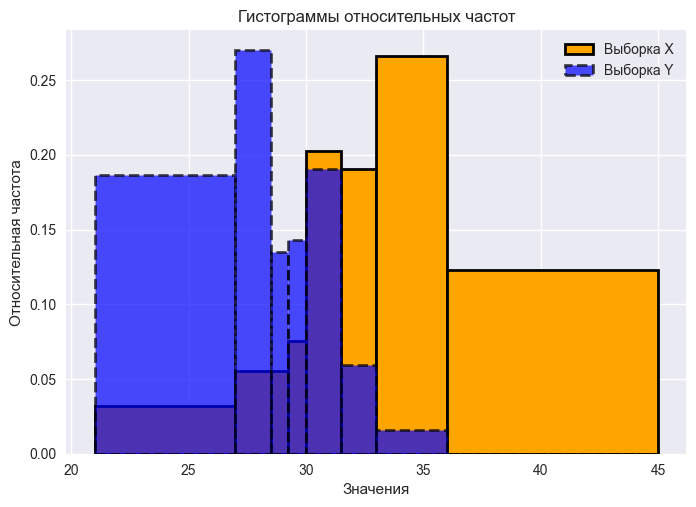

In [260]:
plt.bar(
    (groups["low edge"] + groups["high edge"]) / 2,
    groups["relative frequency1"],
    width=groups["high edge"] - groups["low edge"],
    edgecolor="black",
    label="Выборка X",
    color="orange",
    lw=2,
)

plt.bar(
    (groups["low edge"] + groups["high edge"]) / 2,
    groups["relative frequency2"],
    width=groups["high edge"] - groups["low edge"],
    edgecolor="black",
    label="Выборка Y",
    alpha=0.7,
    linestyle="--",
    lw=2,
    color="blue",
)
plt.legend()
plt.title("Гистограммы относительных частот")
plt.xlabel("Значения")
plt.ylabel("Относительная частота")
plt.show()

### Проверить статистические гипотезы

In [262]:
def chi2_2samp(frequencies1, frequencies2):
    if len(frequencies1) != len(frequencies2):
        raise ValueError("Длины выборок должны совпадать")
    k = len(frequencies1)
    n = sum(frequencies1)
    m = sum(frequencies2)
    z = (n* m* sum((frequencies1 / n - frequencies2 / m) ** 2 / (frequencies1 + frequencies2)))
    p_value = stats.chi2.sf(z, df=k - 1)
    return z, p_value

In [263]:
alphas = [0.01, 0.05, 0.1]

z, p_value = chi2_2samp(groups["frequency1"], groups["frequency2"])
mprint(
    r"### $\chi^2$-test",
    f"$H_0: F_X(x) = F_Y(x)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### $\chi^2$-test

$H_0: F_X(x) = F_Y(x)$

$z_{выб} =$ 181.08

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

<a id="6"></a>

# Раздел 6. Таблицы сопряжённости

## Условие

Факторный признак $x$ - `B3` (Body fat)

Результативный признак $y$ - `B5` (Sex)

Объёмы выборок - $n_1 = n_2 = n = 252$

Статистическая гипотеза $H_0:\ F_Y(y \mid_{X = x^{(1)}}) = F_Y(y \mid_{X = x^{(2)}}) = \dots = F_Y(y \mid_{X = x^{(k_1)}}) = F_Y(y); \quad H':\ \exists i, j: F_Y(y \mid_{X = x^{(i)}}) \neq F_Y(y \mid_{X = x^{(j)})}$

## Определения

In [264]:
X, Y = data("6")
X.head(), Y.head()

(0    normal
 1       low
 2      high
 3    normal
 4      high
 Name: B3, dtype: object,
 0    Male
 1    Male
 2    Male
 3    Male
 4    Male
 Name: B5, dtype: object)

In [265]:
print(n1 := len(X), n2 := len(Y))
if n1 == n2:
    n = n1

252 252


## Указать формулы расчёта показателей, используемых при проверке статистических гипотез

|                                                                                  | Выражение                                                                               | Пояснение использованных обозначений                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| -------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Формула рассчёта статистики критерия                                             | $Z = \sum\limits_{i=1}^{k_1}\sum\limits_{j=1}^{k_2}\dfrac{(n_{ij} - m_{ij})^2}{m_{ij}}$ | $(x_1, y_1), \dots, (x_n, y_n)$ - наблюдения случайного вектора $(X, Y)$, где $X, Y$ - случайные величины дискретного типа $\\$ $x^{(1)}, \dots, x^{(k_1)}$ - варианты признака $X$ $\\$ $y^{(1)}, \dots, y^{(k_2)}$ - варианты признака $Y$ $\\$ $n_{ij}$ - выборочная частота варианта $(x^{(i)}, y^{(j)})$ в выборке $(x_1, y_1), \dots, (x_n, y_n)$ $\\$ $m_{ij}$ - теоретическая частота варианта  $(x^{(i)}, y^{(j)})$ в выборке $(x_1, y_1), \dots, (x_n, y_n)$ при условии истинности $H_0$ |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $\chi^2((k_1 - 1)(k_2 - 1))$                                                            |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| Формула расчета критической точки                                                | $\chi^2_{1 - \alpha,\ (k_1 - 1)(k_2 -1)}$                                               | Правосторонняя критическая область                                                                                                                                                                                                                                                                                                                                                                                                                                                                  |
| Формула расчета p-value                                                          | $1 - F_Z(z_{\text{выб}} \mid H_0)$                                                      |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |


## Построить эмпирическую таблицу сопряжённости

In [266]:
df = pd.DataFrame({"X": X, "Y": Y})
df

,X,Y
0,normal,Male
1,low,Male
2,high,Male
3,normal,Male
4,high,Male
...,...,...
247,normal,Male
248,high,Female
249,high,Female
250,high,Female


In [88]:
emperical_table = pd.crosstab(df["X"], df["Y"], margins=True)
emperical_table

Y,Female,Male,All
X,,,
high,65,55,120
low,8,31,39
normal,20,73,93
All,93,159,252


## Построить теоретическую таблицу сопряжённости

### Теоретическая справка

Пусть $H_0$ верна. Тогда $F_Y(y \mid_{X = x^{(i)}}) = F_Y(y)$. У нас дискретные случайные величины, поэтому это эквивалентно $P\left[Y = y^{(j)} \mid X = x^{(i)}\right] = P\left[Y = y^{(j)}\right]$.

Это значит, что случайные величины $X$ и $Y$ независимы. Значит $P\left[X = x^{(i)}, Y = y^{(j)}\right] = P\left[X = x^{(i)}\right] \cdot P\left[Y = y^{(j)}\right] \Leftrightarrow p_{ij} = p_i \cdot p_j = \sum\limits_{k = 1}^{k_2}p_{ik} \cdot \sum\limits_{l=1}^{k_1}p_{lj}$.

Теоретические частоты отсюда легко находятся: $m_{ij} = n \cdot p_{ij} = n \cdot \sum\limits_{k = 1}^{k_2}p_{ik} \cdot \sum\limits_{l=1}^{k_1}p_{lj} = n \cdot \sum\limits_{k = 1}^{k_2}\dfrac{n_{ik}}{n} \cdot \sum\limits_{l=1}^{k_1}\dfrac{n_{lj}}{n} = \dfrac{\sum\limits_{k = 1}^{k_2}n_{ik} \cdot \sum\limits_{l=1}^{k_1}n_{lj}}{n}$.

Итак, для начала получим матрицу $A = \|a_{ij}\|_{k_1 \times k_2}$, где $a_{ij} = \sum\limits_{k = 1}^{k_2}n_{ik} \cdot \sum\limits_{l=1}^{k_1}n_{lj}$

Матрицу $A$ можно получить простым матричным произведением:

$$
A = \overrightarrow{V_1}^T \cdot \overrightarrow{V_2} = \begin{pmatrix}
\sum\limits_{k = 1}^{k_2}n_{1k} \\
\sum\limits_{k = 1}^{k_2}n_{2k} \\
\vdots \\
\sum\limits_{k = 1}^{k_2}n_{k_1k} \\
\end{pmatrix} \cdot \begin{pmatrix} \sum\limits_{l=1}^{k_1}n_{l1} & \sum\limits_{l=1}^{k_1}n_{l2} & \cdots & \sum\limits_{l=1}^{k_1}n_{lk_2} \end{pmatrix} = 
\begin{pmatrix} 
\sum\limits_{k = 1}^{k_2}n_{1k} \cdot \sum\limits_{l=1}^{k_1}n_{l1} & \cdots & \sum\limits_{k = 1}^{k_2}n_{1k} \cdot \sum\limits_{l=1}^{k_1}n_{lk_2} \\
\cdots & \ddots & \cdots \\
\sum\limits_{k = 1}^{k_2}n_{k_1k} \cdot \sum\limits_{l=1}^{k_1}n_{l1} &  \cdots & \sum\limits_{k = 1}^{k_2}n_{k_1k} \cdot \sum\limits_{l=1}^{k_1}n_{lk_2} \\
\end{pmatrix}
$$


Получаем $\overrightarrow{V_1}^T$:

In [267]:
V1 = np.array(emperical_table.iloc[:-1, -1])
V1

array([120,  39,  93], dtype=int64)

In [268]:
V1 = np.atleast_2d(V1).T
V1

array([[120],
       [ 39],
       [ 93]], dtype=int64)

Получаем $\overrightarrow{V_2}$:

In [269]:
V2 = np.array(emperical_table.iloc[-1][:-1])
V2

array([ 93, 159], dtype=int64)

In [270]:
V2 = np.atleast_2d(V2)
V2

array([[ 93, 159]], dtype=int64)

Получаем матрицу $A$:

In [271]:
A = np.dot(V1, V2)
A

array([[11160, 19080],
       [ 3627,  6201],
       [ 8649, 14787]], dtype=int64)

Строим теоретическую таблицу сопряжённости:

In [275]:
theoretical_table = pd.DataFrame(
    A / n,
    index=emperical_table.index[:-1],
    columns=emperical_table.columns[:-1],
)
theoretical_table

Y,Female,Male
X,,
high,44.285714,75.714286
low,14.392857,24.607143
normal,34.321429,58.678571


Добавим в таблицу суммы по строкам и столбцам:

In [277]:
theoretical_table["All"] = theoretical_table.sum(axis=1)
theoretical_table.loc["All"] = theoretical_table.sum()
theoretical_table

Y,Female,Male,All
X,,,
high,44.285714,75.714286,120.0
low,14.392857,24.607143,39.0
normal,34.321429,58.678571,93.0
All,93.000000,159.000000,252.0


## Проверить статистические гипотезы

In [276]:
alphas = [0.01, 0.05, 0.1]

res = stats.chi2_contingency(emperical_table.iloc[:-1, :-1])
res

Chi2ContingencyResult(statistic=29.327732209282477, pvalue=4.281183740842417e-07, dof=2, expected_freq=array([[44.28571429, 75.71428571],
       [14.39285714, 24.60714286],
       [34.32142857, 58.67857143]]))

In [278]:
z = res.statistic
p = res.pvalue

mprint(
    r"### $\chi^2$-test",
    f"$H_0:\\ F_Y(y \\mid_{{X = x^{{(1)}}}}) = F_Y(y \\mid_{{X = x^{{(2)}}}}) = \\dots = F_Y(y \\mid_{{X = x^{{(k_1)}}}}) = F_Y(y)$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p)}")

### $\chi^2$-test

$H_0:\ F_Y(y \mid_{X = x^{(1)}}) = F_Y(y \mid_{X = x^{(2)}}) = \dots = F_Y(y \mid_{X = x^{(k_1)}}) = F_Y(y)$

$z_{выб} =$ 29.33

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

## Вывод (в терминах предметной области)

В результате проведённого в п.6 статистического анализа обнаружено, что между факторным признаком `B3` и результативным признаком `B5` присутствует статистическая связь. Под действием `B3` оказывается влияние на распределение `B5`.

<a id="7"></a>

# Раздел 7. Дисперсионный анализ

## Условие

Факторный признак $x$ – `B3`  Body fat

Результативный признак $y$ – `B16` Biceps circumference (cm)

Число вариантов факторного признака – $k = 3$

Объёмы выборок – $n_1 = n_2 = n = 252$

Статистическая гипотеза – $H_0:\ F_Y(y \mid_{X = x_1}) = F_Y(y \mid_{X = x_2}) = \dots = F_Y(y \mid_{X = x_k}) = F_Y(y); \quad H':\ \exists i, j: F_Y(y \mid_{X = x_i}) \neq F_Y(y \mid_{X = x_j})$

## Определения

In [279]:
X, Y = data("7")
X.head(), Y.head()

(0    normal
 1       low
 2      high
 3    normal
 4      high
 Name: B3, dtype: object,
 0    32.0
 1    30.5
 2    28.8
 3    32.4
 4    32.2
 Name: B16, dtype: float64)

In [280]:
print(n1 := len(X), n2 := len(Y))
if n1 == n2:
    n = n1

252 252


In [281]:
print(k := len(X.unique()))

3


## Рассчитать групповые выборочные характеристики

In [283]:
df = pd.DataFrame({"X": X, "Y": Y}).groupby("X")["Y"].apply(np.array).to_frame()
df

,Y
X,
high,"[28.8, 32.2, 35.7, 32.5, 36.9, 36.1, 31.1, 36...."
low,"[30.5, 35.9, 32.8, 37.2, 29.9, 28.7, 30.5, 30...."
normal,"[32.0, 32.4, 31.9, 30.5, 35.6, 37.2, 37.1, 32...."


In [288]:
groups = pd.DataFrame(index=pd.Index(range(1, k + 1), name="№ п/п"))
groups[r"x^(i)"] = df.index
groups[r"n_i"] = df["Y"].apply(len).values
groups[r"y_i"] = df["Y"].apply(np.mean).values
groups[r"s_i^2"] = df["Y"].apply(np.var, ddof=0).values
groups

,x^(i),n_i,y_i,s_i^2
№ п/п,,,,
1,high,120,33.515833,7.185666
2,low,39,30.238462,7.926982
3,normal,93,31.523656,7.749548


## Привести формулы расчёта показателей вариации, используемых в дисперсионном анализе

| Источник вариации      | Показатель вариации                                                                                                                                                                                     | Число степеней свободы | Несмещённая оценка                         |
| ---------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------- | ------------------------------------------ |
| Группировочный признак | $\tilde{D}_{\text{межгр}} = \dfrac{1}{n}\sum\limits_{i=1}^{k}n_i(\overline{y_i} - \overline{y})^2$                                                                                                      | $k - 1$                | $\dfrac{n}{k - 1}\tilde{D}_{\text{межгр}}$ |
| Остаточные факторы     | $\tilde{D}_{\text{внутр}} = \dfrac{1}{n}\sum\limits_{i=1}^{k}n_i\tilde{\sigma_i}^2$, где $\tilde{\sigma_i}^2 =  \dfrac{1}{n_i}\sum\limits_{j=1}^{n_i}(y_{ij} - \overline{y_i}^2)$ - групповая дисперсия | $n - k$                | $\dfrac{n}{n - k}\tilde{D}_{\text{внутр}}$ |
| Все факторы            | $\tilde{D}_{\text{общ}} = \dfrac{1}{n}\sum\limits_{i=1}^{k}\sum\limits_{j=1}^{n_i}(y_{ij}-\overline{y})^2$                                                                                              | $n - 1 $               | $\dfrac{n}{n - 1}\tilde{D}_{\text{общ}}$   |

## Рассчитать показатели вариации, используемые в дисперсионном анализе

In [290]:



S_general = float(Y.var(ddof=0))
S_inside = 1 / n * sum(groups[r"n_i"] * groups[r"s_i^2"])
S_between = (
    1 / n * sum(groups[r"n_i"] * (groups[r"y_i"] - Y.mean()) ** 2)
)

S_general_unbiased = S_general * n / (n - 1)
S_inside_unbiased = S_inside * n / (n - k)
S_between_unbiased = S_between * n / (k - 1)

mprint(
    f"$\\tilde{{D}}_{{\\text{{межгр}}}} = {S_between:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{внутр}}}} = {S_inside:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{общ}}}} = {S_general:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{межгр, несмещ}}}} = {S_between_unbiased:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{внутр, несмещ}}}} = {S_inside_unbiased:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{общ, несмещ}}}} = {S_general_unbiased:.2f}$",
)

$\tilde{D}_{\text{межгр}} = 1.58$

$\tilde{D}_{\text{внутр}} = 7.51$

$\tilde{D}_{\text{общ}} = 9.09$

$\tilde{D}_{\text{межгр, несмещ}} = 199.51$

$\tilde{D}_{\text{внутр, несмещ}} = 7.60$

$\tilde{D}_{\text{общ, несмещ}} = 9.13$

## Проверить правило сложения дисперсий

In [291]:
mprint(
    f"$\\tilde{{D}}_{{\\text{{межгр}}}} = {S_between:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{внутр}}}} = {S_inside:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{общ}}}} = {S_general:.2f}$",
    f"$\\tilde{{D}}_{{\\text{{межгр}}}} + \\tilde{{D}}_{{\\text{{внутр}}}} = {S_between + S_inside:.2f}$",
)
print(S_between + S_inside - S_general < 1e-10)

$\tilde{D}_{\text{межгр}} = 1.58$

$\tilde{D}_{\text{внутр}} = 7.51$

$\tilde{D}_{\text{общ}} = 9.09$

$\tilde{D}_{\text{межгр}} + \tilde{D}_{\text{внутр}} = 9.09$

True


## Рассчитать показатели тесноты связи между факторным и результативным признаками

| Показатель                            | Формула расчета                                                                                          | Значение |
| ------------------------------------- | -------------------------------------------------------------------------------------------------------- | -------- |
| Эмпирический коэффициент детерминации | $\tilde{\eta}^2 = \dfrac{\tilde{D}_{\text{межгр}}}{\tilde{D}_{\text{общ}}}$                              | 0.17     |
| Эмпирическое корреляционное отношение | $\tilde{\eta} = \sqrt{\tilde{\eta}^2} = \sqrt{\dfrac{\tilde{D}_{\text{межгр}}}{\tilde{D}_{\text{общ}}}}$ | 0.42     |


In [292]:
eta_squared = S_between / S_general

eta = m.sqrt(eta_squared)

mprint(
    f"$\\tilde{{\\eta^2}} = {eta_squared:.2f}$",
    f"$\\tilde{{\\eta}} = {eta:.2f}$",
)

$\tilde{\eta^2} = 0.17$

$\tilde{\eta} = 0.42$

## Указать формулы расчёта показателей, используемых при проверке статистической гипотезы дисперсионного анализа

|                                                                                  | Выражение                                                                        | Пояснение использованных обозначений                         |
| -------------------------------------------------------------------------------- | -------------------------------------------------------------------------------- | ------------------------------------------------------------ |
| Формула рассчёта статистики критерия                                             | $Z = \dfrac{n-k}{k-1}\dfrac{\tilde{D}_{\text{межгр}}}{\tilde{D}_{\text{внутр}}}$ | $k$ - число групп $\\$ $n$ - объём выборки $y_1, \dots, y_n$ |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $F(k-1, n-k)$                                                                    |                                                              |
| Формула расчета критической точки                                                | $F_{1-\alpha, k-1, n-k}$                                                         | Правосторонняя критическая область                           |
| Формула расчета p-value                                                          | $1 - F_Z(z_{\text{выб}} \mid H_0)$                                               |                                                              |


## Проверить статистическую гипотезу дисперсионного анализа

In [295]:
alphas = [0.01, 0.05, 0.1]

z, p_value = stats.f_oneway(*df["Y"])

mprint(
    r"### ANOVA",
    f"$H_0: m_1 = m_2 = m_3$",
    f"$z_{{выб}} = {z:.2f}$",
    f"$p = {p_value:.2f}$",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### ANOVA

$H_0: m_1 = m_2 = m_3$

$z_{выб} = 26.25$

$p = 0.00$

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

<a id="8"></a>

# Раздел 8. Корреляционный анализ

<a id="81"></a>

## 8.1 Расчёт парных коэффициентов корреляции

### Условие

Анализируемый признак 1 – `B16` Biceps circumference (cm)

Анализируемый признак 2 – `B17` Forearm circumference (cm)

Объёмы выборок – $n_1 = n_2 = n = 252$

### Определения

In [297]:
X, Y = data("8.1")
X.head(), Y.head()

(0    32.0
 1    30.5
 2    28.8
 3    32.4
 4    32.2
 Name: B16, dtype: float64,
 0    27.4
 1    28.9
 2    25.2
 3    29.4
 4    27.7
 Name: B17, dtype: float64)

In [298]:
print(n1 := len(X), n2 := len(Y))

if n1 == n2:
    n = n1

252 252


### Рассчитать точечные оценки коэффициентов корреляции

In [299]:
r_XY = stats.pearsonr(X, Y)[0]
r_sp_XY = stats.spearmanr(X, Y)[0]
tau_XY = stats.kendalltau(X, Y)[0]

mprint(
    f"$\\rho_{{XY}} = {r_XY:.2f}$",
    f"$\\rho^{{(sp)}}_{{XY}} = {r_sp_XY:.2f}$",
    f"$\\tau_{{XY}} = {tau_XY:.2f}$",
)

$\rho_{XY} = 0.68$

$\rho^{(sp)}_{XY} = 0.76$

$\tau_{XY} = 0.60$

|                                             | Формула расчёта                                                                                                                                                                                                                                                                                                                                                                                                                                                                    | Значение |
| ------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------- |
| Линейный коэффициент корреляции             | $\tilde{\rho}_{XY} = \dfrac{\tilde{cov}(X, Y)}{\tilde{\sigma}_X \cdot \tilde{\sigma}_Y} = \dfrac{\sum\limits_{i=1}^{n}(x_i - \overline{x})(y_i - \overline{y})}{\sqrt{\sum\limits_{i=1}^{n}(x_i - \overline x)^2 \cdot \sum\limits_{i=1}^{n} (y_i - \overline y)^2}}$                                                                                                                                                                                                              | 0.87     |
| Ранговый коэффициент корреляции по Спирмену | $\tilde{\rho}^{(sp)}_{XY} = \tilde{\rho}_{RS}$, где $R$ и $S$ - ранги для выборок $X$ и $Y$ соответственно. $\\$ Можно показать, что $\tilde{\rho}^{(sp)}_{XY} = 1 - \dfrac{6S}{n(n^2 - 1)}$, где $S = \sum\limits_{i=1}^{n} (r_i - s_i)^2$                                                                                                                                                                                                                                        | 0.85     |
| Ранговый коэффициент корреляции по Кендаллу | $\tilde{\tau}_{XY} = \dfrac{N_+ - N_-}{n(n-1)/2}$,  где $\\$ $N_+,\  N_-$ - количество пар точек $(x_i, y_i)$ таких, что $\\$ $(x_i - x_j)(y_i - y_j) > 0,\ (x_i - x_j)(y_i - y_j) < 0$ соответственно. $\\$ Другой вариант расчёта:   $\tilde{\tau}_{XY} = \dfrac{4R}{n(n-1)} - 1$, где $\\$ $R = \sum\limits_{i=1}^{n}\sum\limits_{j=i+1}^{n}1[s_j > s_i]$ - число инверсий в выборке $(r_1, s_1), \dots, (r_n, s_n)$, $\\$ предварительно отсортированной по возрастанию $r_i$. | 0.66     |


### Привести формулы расчёта доверительного интервала для линейного коэффициента корреляции

Для выборок объёмов  $n \leq 500$

| Граница доверительного интервала | Формула расчёта |
| -------------------------------- | --------------- |
| Нижняя граница                   |$\th{\left(\dfrac{1}{2}\ln{\dfrac{1 + \tilde{\rho}}{1 - \tilde{\rho}}} + \dfrac{\tilde{\rho}}{2(n-1)}-\dfrac{u_{1 - \frac{\alpha}{2}}}{\sqrt{n-3}}\right)}$|
| Верхняя граница                  |  $\th{\left(\dfrac{1}{2}\ln{\dfrac{1 + \tilde{\rho}}{1 - \tilde{\rho}}} + \dfrac{\tilde{\rho}}{2(n-1)}+\dfrac{u_{1 - \frac{\alpha}{2}}}{\sqrt{n-3}}\right)}$               |


### Рассчитать доверительные интервалы для линейного коэффициента корреляции

In [301]:
intervals = pd.DataFrame(
    index=pd.Index(
        ["Нижняя граница", "Верхняя граница"], name="Граница доверительного интервала"
    )
)
alphas = [0.01, 0.05, 0.1]
for alpha in alphas:
    u = stats.norm.ppf(1 - alpha / 2)
    z1 = (
        1 / 2 * m.log((1 + r_XY) / (1 - r_XY))
        + r_XY / (2 * (n - 1))
        - u / m.sqrt(n - 3)
    )
    z2 = (
        1 / 2 * m.log((1 + r_XY) / (1 - r_XY))
        + r_XY / (2 * (n - 1))
        + u / m.sqrt(n - 3)
    )
    intervals[f"alpha = {alpha}"] = [m.tanh(z1), m.tanh(z2)]
intervals

,alpha = 0.01,alpha = 0.05,alpha = 0.1
Граница доверительного интервала,,,
Нижняя граница,0.581013,0.606281,0.618757
Верхняя граница,0.757560,0.740432,0.731276


### Указать формулы расчёта показателей, используемых при проверке значимости коэффициентов корреляции(статистики)

| Статистическая гипотеза                                      | Формула расчёта статистики критерия                                                                          | Закон распределения статистики критерия при условии истинности основной |
| ------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------ | ----------------------------------------------------------------------- |
| $H_0:\ \rho_{XY} = 0 \\ H':\ \rho_{XY} \neq 0$               | $Z =  \dfrac{\tilde{\rho}_{XY} \cdot \sqrt{n-2}}{\sqrt{1 - \tilde{\rho}_{XY}^2}}$                            | $T(n - 2)$                                                              |
| $H_0:\ \rho_{XY}^{(sp)} = 0 \\ H':\ \rho_{XY}^{(sp)} \neq 0$ | $Z =  \dfrac{\tilde{\rho}_{XY}^{(sp)} \cdot \sqrt{n-2}}{\sqrt{1 - \left(\tilde{\rho}_{XY}^{(sp)}\right)^2}}$ | $T(n - 2)$                                                              |
| $H_0:\ \tau_{XY} = 0 \\ H':\ \tau_{XY} \neq 0$               | $\sqrt{\dfrac{9n(n+1)}{2(2n+5)}}\cdot \tilde{\tau}_{XY}$                                                     | $N(0, 1)$                                                               |


### Проверить значимость коэффициентов корреляции

In [ ]:
alpha = 0.1

z_rho_XY = r_XY * m.sqrt(n - 2) / m.sqrt(1 - r_XY**2)
p_rho_XY = stats.pearsonr(X, Y)[1]

z_rho_sp_XY = r_sp_XY * m.sqrt(n - 2) / m.sqrt(1 - r_sp_XY**2)
p_rho_sp_XY = stats.spearmanr(X, Y)[1]

z_tau_XY = tau_XY * m.sqrt(9 * n * (n + 1)) / m.sqrt(2 * (2 * n + 5))
p_tau_XY = stats.kendalltau(X, Y)[1]

mprint(
    r"### Проверка значимости КК",
    r"---",
    r"### $\rho_{XY}$",
    f"$H_0$: $\\rho_{{XY}} = 0$, $H_1$: $\\rho_{{XY}} \\neq 0$",
    f"$z_{{выб}} =$ {z_rho_XY:.2f}, ",
    f"$p =$ {p_rho_XY:.2f}",
    verdict(alpha, p_rho_XY),
    r"---",
    r"### $\rho_{XY}^{(sp)}$",
    f"$H_0$: $\\rho_{{XY}}^{{(sp)}} = 0$, $H_1$: $\\rho_{{XY}}^{{(sp)}} \\neq 0$",
    f"$z_{{выб}} =$ {z_rho_sp_XY:.2f}, ",
    f"$p =$ {p_rho_sp_XY:.2f}",
    verdict(alpha, p_rho_sp_XY),
    r"---",
    r"### $\tau_{XY}$",
    f"$H_0$: $\\tau_{{XY}} = 0$, $H_1$: $\\tau_{{XY}} \\neq 0$",
    f"$z_{{выб}} =$ {z_tau_XY:.2f}, ",
    f"$p =$ {p_tau_XY:.2f}",
    verdict(alpha, p_tau_XY),
)

### Проверка значимости КК

---

### $\rho_{XY}$

$H_0$: $\rho_{XY} = 0$, $H_1$: $\rho_{XY} \neq 0$

$z_{выб} =$ 14.59, 

...

### $\tau_{XY}$

$H_0$: $\tau_{XY} = 0$, $H_1$: $\tau_{XY} \neq 0$

$z_{выб} =$ 14.31, 

$p =$ 0.00

$H_0$ отклоняется

<a id="82"></a>

## 8.2 Расчёт множественных коэффициентов корреляции

### Условие

Анализируемый признак 1 – `B16` Biceps circumference (cm)

Анализируемый признак 2 – `B17` Forearm circumference (cm)

Анализируемый признак 3 – `B18` Wrist circumference (cm)

Объёмы выборок – $n = 252$

### Определения

In [322]:
X = pd.concat(data("8.2"), axis=1)
X.head()

,B16,B17,B18
0,32.0,27.4,17.1
1,30.5,28.9,18.2
2,28.8,25.2,16.6
3,32.4,29.4,18.2
4,32.2,27.7,17.7


In [304]:
print(n := len(X))

252


In [305]:
print(k := X.shape[1])

3


### Рассчитать матрицу ранговых коэффициентов корреляции по Кендаллу

In [313]:
kendall_matrix = pd.DataFrame(
    np.zeros((X.shape[1], X.shape[1])), index=X.columns, columns=X.columns
)
kendall_matrix.index.name = "Признак"
kendall_matrix.columns.name = "Признак"

p_value_matrix = pd.DataFrame(
    np.zeros((X.shape[1], X.shape[1])), index=X.columns, columns=X.columns
)
p_value_matrix.index.name = "Признак"
p_value_matrix.columns.name = "Признак"

for i, col1 in enumerate(X.columns):
    for j, col2 in enumerate(X.columns):
        if i >= j:
            tau, p_value = stats.kendalltau(X[col1], X[col2])
            kendall_matrix.loc[col1, col2] = kendall_matrix.loc[col2, col1] = tau
            p_value_matrix.loc[col1, col2] = p_value_matrix.loc[col2, col1] = p_value


In [314]:
kendall_matrix


Признак,B16,B17,B18
Признак,,,
B16,1.000000,0.602929,0.435948
B17,0.602929,1.000000,0.490008
B18,0.435948,0.490008,1.000000


### Рассчитать матрицу значений $p$-value для ранговых коэффициентов корреляции по Кендаллу

Статистическая гипотеза: $H_0:\ \tau = 0; \ \ \ H':\ \tau \neq 0$

In [323]:
p_value_matrix

Признак,B16,B17,B18
Признак,,,
B16,1.412640e-121,3.750373e-45,5.444522e-24
B17,3.750373e-45,2.325551e-120,9.860756e-30
B18,5.444522e-24,9.860756e-30,4.834153e-116


### Рассчитать точечную оценку коэффициента конкордации

$k = 3$ - число выборок.

$n = 252$ - объём каждой выборки.

$\tilde{W} = \dfrac{12}{k^2(n^3 - n)}\sum\limits_{i=1}^{n}\left(\sum\limits_{j=1}^{k}r_{ij} - \dfrac{k(n+1)}{2}\right)^2$, где $r_{ij}$ - ранг $i$-го объекта в $j$-й выборке.

In [124]:
ranks = X.rank()
ranks.columns.name = "Выборка"
ranks.index.name = "№ объекта"
ranks

Выборка,B16,B17,B18
№ объекта,,,
0,125.0,70.0,30.5
1,73.0,133.5,118.0
2,28.5,8.0,9.5
3,135.5,156.5,118.0
4,132.0,82.0,77.0
...,...,...,...
247,3.0,12.5,157.5
248,204.5,120.5,246.5
249,99.5,55.5,99.5


In [324]:
W = 12 / (k**2 * (n**3 - n)) * sum((ranks.sum(axis=1) - k * (n + 1) / 2) ** 2)

print(f"{W = :.2f}")

W = 0.78


|                         | Формула расчёта                                                                                                                                                                                                                     | Значение |
| ----------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------- |
| Коэффициент конкордации | $\tilde{W} = \dfrac{12}{k^2(n^3 - n)}\sum\limits_{i=1}^{n}\left(\sum\limits_{j=1}^{k}r_{ij} - \dfrac{k(n+1)}{2}\right)^2$, где $\\r_{ij}$ - ранг $i$-го объекта в $j$-й выборке. $\\k$ - количество выборок. $\\n$ - объём выборок. | 0.70     |


### Указать формулы расчёта показателей, используемых при проверке значимости коэффициента конкордации

Статистическая гипотеза: $H_0:\ W = 0; \quad H':\ W \neq 0$.

|                                                                                  | Выражение                        | Пояснение использованных обозначений                                                                       |
| -------------------------------------------------------------------------------- | -------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| Формула расчёта статистики критерия                                              | $Z = n(k-1)\tilde{W}$            | $\tilde W$ - точечная оценка коэффициента конкордации. $\\n$ - объём выборок. $\\k$ - количество выборок |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $\chi^2(n-1)$                    |                                                                                                            |
| Формула расчёта критической точки                                                | $\chi^2_{1 - \alpha, n-1}$       | Правосторонняя критическая область                                                                         |
| Формула расчёта $p$-value                                                        | $1 - F_Z(z_{\text{выб}} \mid H_0)$ |                                                                                                            |


### Проверить значимость коэффициента конкордации

In [325]:
alphas = [0.01, 0.05, 0.1]

z = n * (k - 1) * W
p_value = stats.chi2.sf(z, df=n - 1)

mprint(
    r"### Проверка значимости $W$",
    f"$H_0$: $W = 0$, $H_1$: $W \\neq 0$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### Проверка значимости $W$

$H_0$: $W = 0$, $H_1$: $W \neq 0$

$z_{выб} =$ 392.41

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

<a id="9"></a>

# Раздел 9. Регрессионный анализ

<a id="91"></a>

## 9.1 Простейшая линейная регрессионная модель

### Условие

Факторный признак $x$ - `B16`  	Biceps circumference (cm)

Результативный признак $y$ - `B2` (Percent body fat from Siri's equation)

Уравнение регрессии - $f(x) = \beta_0 + \beta_1x$

### Определения

In [326]:
X, Y = data("9.1")
X.head(), Y.head()

(0    32.0
 1    30.5
 2    28.8
 3    32.4
 4    32.2
 Name: B16, dtype: float64,
 0    12.3
 1     6.1
 2    25.3
 3    10.4
 4    28.7
 Name: B2, dtype: float64)

In [327]:
print(n1 := len(X), n2 := len(Y))

if n1 == n2:
    n = n1

252 252


In [328]:
k = 2

### 9.1.1. Точечные оценки линейной регрессионной модели

#### Рассчитать точечные оценки параметров линейной регрессионной модели

In [333]:
result = stats.linregress(X, Y)
slope, intercept, r_value, p_value, slope_std_err, intercept_std_err = (
    result.slope,
    result.intercept,
    result.rvalue,
    result.pvalue,
    result.stderr,
    result.intercept_stderr,
)

mprint(
    f"$\\tilde{{\\beta_0}} =$ {intercept:.2f}",
    f"$\\tilde{{\\beta_1}} =$ {slope:.2f}",
)

$\tilde{\beta_0} =$ -24.95

$\tilde{\beta_1} =$ 1.37

| Параметр  | Формула расчета                                                                                      | Значение |
| --------- | ---------------------------------------------------------------------------------------------------- | -------- |
| $\beta_0$ | $\overline y - \tilde{\rho}_{XY} \cdot \dfrac{\tilde{\sigma}_Y}{\tilde{\sigma}_X} \cdot \overline x$ | -24.95   |
| $\beta_1$ | $\tilde{\rho}_{XY} \cdot \dfrac{\tilde{\sigma}_Y}{\tilde{\sigma}_X}$                                 | 1.37  |


#### Записать точечную оценку уравнения регрессии

$\tilde{f}(x) = \tilde{\beta_0} + \tilde{\beta_1}x = -24.95 - 1.37x$

In [466]:
def f(x):
    return intercept + slope * x

#### Привести формулы расчёта показателей вариации, используемых в регрессионном анализе

| Источник вариации   | Показатель вариации                                                                 | Число степеней свободы | Несмещённая оценка                          |
| ------------------- | ----------------------------------------------------------------------------------- | ---------------------- | ------------------------------------------- |
| Регрессия           | $\tilde{D}_{Y \mid X} = \dfrac{1}{n}\sum\limits_{i=1}^{n}(\tilde f(x_i) - \overline y)^2$  | $k - 1$                | $\dfrac{n}{k - 1}\tilde{D}_{Y \mid X}$      |
| Остаточные признаки | $\tilde{D}_{Y\text{ ост}} = \dfrac{1}{n}\sum\limits_{i=1}^{n}(\tilde f(x_i) - y_i)^2$      | $n - k$                | $\dfrac{n}{n - k}\tilde{D}_{Y\text{ ост}}$  |
| Все признаки        | $\tilde{D}_{Y \text{ общ}} = \dfrac{1}{n}\sum\limits_{i=1}^{n}(y_i-\overline{y})^2$ | $n - 1 $               | $\dfrac{n}{n - 1}\tilde{D}_{Y \text{ общ}}$ |

$k$ - число оцениваемых параметров функции регрессии $f(x)$.

#### Рассчитать показатели вариации, используемые в регрессионном анализе

In [467]:
D_YX = sum((f(X) - Y.mean()) ** 2) / n
D_resY = sum((f(X) - Y) ** 2) / n
D_Y = Y.var(ddof=0)

D_YX_unbiased = D_YX * n / (k - 1)
D_resY_unbiased = D_resY * n / (n - k)
D_Y_unbiased = D_Y * n / (n - 1)

mprint(
    f"$\\tilde{{D}}_{{Y \\mid X}} =$ {D_YX:.2f}",
    f"$\\tilde{{D}}_{{Y ост}} =$ {D_resY:.2f}",
    f"$\\tilde{{D}}_{{Y общ}} =$ {D_Y:.2f}",
    f"$\\tilde{{D}}_{{Y \\mid X, несмещ}} =$ {D_YX_unbiased:.2f}",
    f"$\\tilde{{D}}_{{Y ост, несмещ}} =$ {D_resY_unbiased:.2f}",
    f"$\\tilde{{D}}_{{Y общ, несмещ}} =$ {D_Y_unbiased:.2f}",
)

$\tilde{D}_{Y \mid X} =$ 16.97

$\tilde{D}_{Y ост} =$ 52.78

$\tilde{D}_{Y общ} =$ 69.76

$\tilde{D}_{Y \mid X, несмещ} =$ 611.04

$\tilde{D}_{Y ост, несмещ} =$ 54.52

$\tilde{D}_{Y общ, несмещ} =$ 70.04

#### Проверить правило сложения дисперсий

In [337]:
mprint(
    f"$\\tilde{{D}}_{{Y \\mid X}} =$ {D_YX:.2f}",
    f"$\\tilde{{D}}_{{Y ост}} =$ {D_resY:.2f}",
    f"$\\tilde{{D}}_{{Y общ}} =$ {D_Y:.2f}",
    f"$\\tilde{{D}}_{{Y \\mid X}} + \\tilde{{D}}_{{Y ост}} =$ {D_YX + D_resY:.2f}",
)
print(D_YX + D_resY - D_Y < 1e-10)

$\tilde{D}_{Y \mid X} =$ 16.97

$\tilde{D}_{Y ост} =$ 52.78

$\tilde{D}_{Y общ} =$ 69.76

$\tilde{D}_{Y \mid X} + \tilde{D}_{Y ост} =$ 69.76

True


#### Рассчитать показатели тесноты связи между факторным и результативным признаками

In [338]:
mprint(
    f"$\\tilde{{R^2}} = {r_value ** 2:.2f}$",
    f"$\\tilde{{R}} = {r_value:.2f}$",
)

$\tilde{R^2} = 0.24$

$\tilde{R} = 0.49$

### 9.1.2. Интервальные оценки линейной регрессионной модели

#### Привести формулы расчёта доверительных интервалов для параметров линейной регрессионной модели

| Параметр  | Границы доверительного интервала | Формула расчета                                                                                                                                             |
| --------- | -------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| $\beta_0$ | Нижняя граница                   | $\tilde{\beta}_0 - t_{1 - \frac{\alpha}{2},\ (n-2)} \cdot \sqrt{\tilde{D}_{Y ост}^{несмещ}} \cdot \sqrt{\dfrac{\sum\limits_{i=1}^n x_i^2}{n^2\tilde{D}_X}}$ |
| $\beta_0$ | Верхняя граница                  | $\tilde{\beta}_0 + t_{1 - \frac{\alpha}{2},\ (n-2)} \cdot \sqrt{\tilde{D}_{Y ост}^{несмещ}} \cdot \sqrt{\dfrac{\sum\limits_{i=1}^n x_i^2}{n^2\tilde{D}_X}}$ |
| $\beta_1$ | Нижняя граница                   | $\tilde{\beta}_1 - t_{1 - \frac{\alpha}{2},\ (n-2)} \cdot \sqrt{\tilde{D}_{Y ост}^{несмещ}} \cdot \sqrt{\dfrac{1}{n\tilde{D}_X}}$                           |
| $\beta_1$ | Верхняя граница                  | $\tilde{\beta}_1 + t_{1 - \frac{\alpha}{2},\ (n-2)} \cdot \sqrt{\tilde{D}_{Y ост}^{несмещ}} \cdot \sqrt{\dfrac{1}{n\tilde{D}_X}}$                           |


#### Рассчитать доверительные интервалы для параметров линейной регрессионной модели

In [342]:
intervals = pd.DataFrame(
    index=pd.Index([r"beta_0"] * 2 + [r"beta1"] * 2, name="Параметр")
)
intervals["Границы доверительного интервала"] = [
    "Нижняя граница",
    "Верхняя граница",
] * 2

alphas = [0.01, 0.05, 0.1]
for alpha in alphas:
    intervals[f"alpha = {alpha}"] = list(
        stats.t.interval(1 - alpha, df=n - 2, scale=intercept_std_err, loc=intercept)
    ) + list(stats.t.interval(1 - alpha, df=n - 2, scale=slope_std_err, loc=slope))

intervals

,Границы доверительного интервала,alpha = 0.01,alpha = 0.05,alpha = 0.1
Параметр,,,,
beta_0,Нижняя граница,-37.766688,-34.673828,-33.100442
beta_0,Верхняя граница,-12.124011,-15.216870,-16.790257
beta1,Нижняя граница,0.970780,1.066198,1.114738
beta1,Верхняя граница,1.761880,1.666463,1.617922


#### Привести формулы расчёта доверительного интервала для значений регрессии $f(x)$

| Границы доверительного интервала | Формула расчета                                                                                                                                                                          |
| -------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Нижняя граница $f_{low}(x)$      | $(\tilde{\beta}_0 + \tilde{\beta}_1x) - t_{1 - \frac{\alpha}{2},\ (n-2)} \cdot \sqrt{\tilde{D}_{Y ост}^{несмещ}} \cdot \sqrt{\dfrac{1}{n} + \dfrac{(x - \overline x)^2}{n \tilde{D}_X}}$ |
| Верхняя граница $f_{high}(x)$    | $(\tilde{\beta}_0 + \tilde{\beta}_1x) + t_{1 - \frac{\alpha}{2},\ (n-2)} \cdot \sqrt{\tilde{D}_{Y ост}^{несмещ}} \cdot \sqrt{\dfrac{1}{n} + \dfrac{(x - \overline x)^2}{n \tilde{D}_X}}$ |


#### Построить диаграмму рассеяния признаков $x$ и $y$. Нанести на диаграмму функцию регрессии $f(x)$, а также нижние и верхние границы линии регрессии $f_{low}(x)$ и $f_{high}(x)$ на уровне значимости $\alpha = 0.1$.

In [343]:
alpha = 0.1

In [345]:
def f_intervals(x):
    std_err = m.sqrt(D_resY_unbiased) * m.sqrt(
        1 / n + (x - X.mean()) ** 2 / (n * X.var(ddof=0))
    )
    return stats.t.interval(
        1 - alpha, df=n - 2, loc=(intercept + slope * x), scale=std_err
    )

In [346]:
table = pd.DataFrame(
    np.column_stack(
        [
            X,
            Y,
            f(X),
            X.apply(f_intervals).apply(lambda x: x[0]),
            X.apply(f_intervals).apply(lambda x: x[1]),
        ]
    ),
    columns=["x", "y", "f(x)", "f_low(x)", "f_high(x)"],
)
table.sort_values("x", inplace=True)
table

,x,y,f(x),f_low(x),f_high(x)
171,24.8,0.7,8.939643,6.912121,10.967165
225,25.3,12.5,9.622808,7.711366,11.534251
247,25.6,11.0,10.032707,8.190300,11.875115
148,25.8,5.3,10.305973,8.509301,12.102646
50,26.0,10.2,10.579240,8.828051,12.330428
...,...,...,...,...,...
221,38.4,26.0,27.521736,25.803767,29.239704
53,38.5,6.3,27.658369,25.917791,29.398946
151,38.5,19.6,27.658369,25.917791,29.398946
179,39.1,16.9,28.478167,26.600573,30.355761


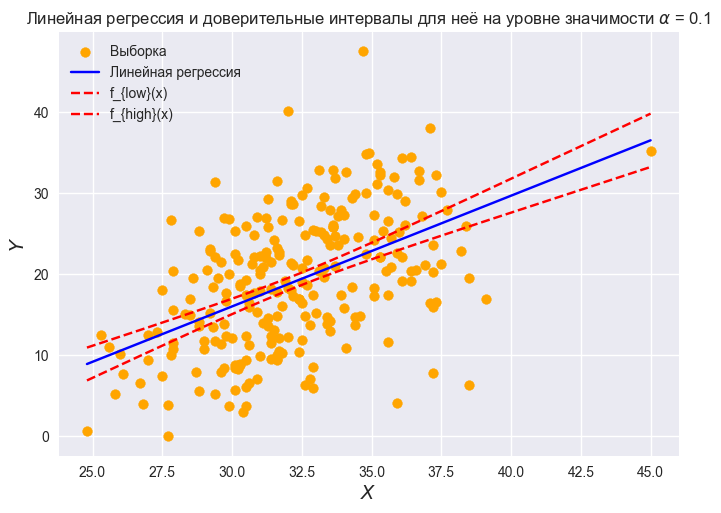

In [349]:
plt.scatter(X, Y, label="Выборка", color="orange")
plt.plot(
    table["x"],
    table["f(x)"],
    label="Линейная регрессия",
    color="blue",
)

plt.plot(
    table["x"], table["f_low(x)"], label=r"f_{low}(x)", color="red", linestyle="--"
)
plt.plot(
    table["x"], table["f_high(x)"], label=r"f_{high}(x)", color="red", linestyle="--"
)

plt.legend()
plt.xlabel("$X$", fontsize=14)
plt.ylabel("$Y$", fontsize=14)
plt.title(
    r"Линейная регрессия и доверительные интервалы для неё на уровне значимости $\alpha$ = 0.1"
)
plt.show()

#### Построить график остатков $\varepsilon(x) = y - f(x)$

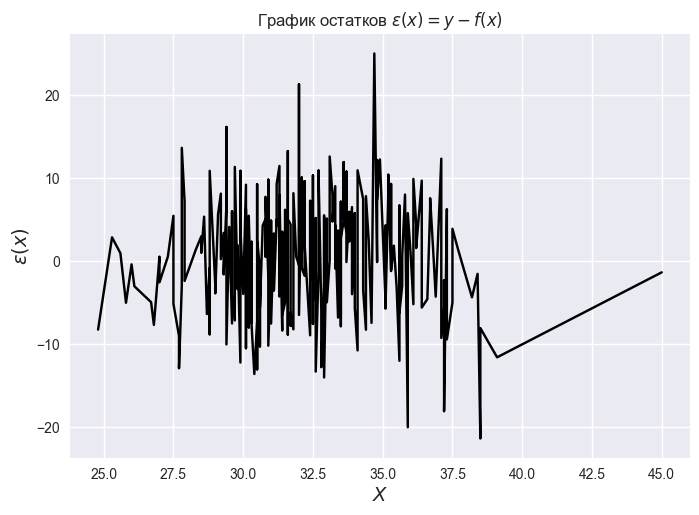

In [353]:
plt.plot(table["x"], table["y"] - table["f(x)"], color="black")
plt.xlabel("$X$", fontsize=14)
plt.ylabel(r"$\varepsilon(x)$", fontsize=14)
plt.title(r"График остатков $\varepsilon(x) = y - f(x)$")
plt.show()

### 9.1.3. Проверка значимости линейной регрессионной модели

Статистическая гипотеза $H_0:\ \beta_1 = 0; \quad H':\ \beta_1 \neq 0$.

#### Указать формулы расчёта показателей, используемых при проверке значимости линейной регрессионной модели

|                                                                                  | Выражение                                                       | Пояснение использованных обозначений                |
| -------------------------------------------------------------------------------- | --------------------------------------------------------------- | --------------------------------------------------- |
| Формула расчёта статистики критерия                                              | $Z = \dfrac{\tilde{D}_{Y \mid X}}{\tilde{D}_{Y ост} / (n - 2)}$ | $n$ - объём выборки $(x_1, y_1), \dots, (x_n, y_n)$ |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $F(1,\ n-2)$                                                    |                                                     |
| Формулы расчёта критической точки                                                | $F_{1 - \alpha,\ 1,\ n-2}$                                      | Правосторонняя критическая область.                 |
| Формула расчёта $p$-value                                                        | $1 - F_Z(z_{\text{выб}} \mid H_0)$                              |                                                     |

#### Проверить значимость линейной регрессионной модели

`r_value` - выборочное значение коэффициента корреляции Пирсона $\tilde \rho^2_{XY}$. При линейной регрессии квадрат этого значения равен коэффициенту детерминации: $\tilde{\rho}_{XY}^2 = \tilde{R}^2$.

Статистику критерия же можно переписать как $Z = \dfrac{\tilde R^2}{(1 - \tilde R^2) / (n - 2)}$. Значение `p_value` у нас уже есть из функции `stats.linregress`.

In [357]:
alphas = [0.01, 0.05, 0.1]

z = r_value**2 * (n - 2) / (1 - r_value**2)

mprint(
    r"### Проверка значимости линейной регрессии",
    f"$H_0$: $\\beta_1 = 0$, $H_1$: $\\beta_1 \\neq 0$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### Проверка значимости линейной регрессии

$H_0$: $\beta_1 = 0$, $H_1$: $\beta_1 \neq 0$

$z_{выб} =$ 80.39

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

<a id="92"></a>

## 9.2 Линейная регрессионная модель общего вида

### Условие

Факторный признак $x$ - `B16`  	Biceps circumference (cm)

Результативный признак $y$ - `B2` (Percent body fat from Siri's equation)

Уравнение регрессии (квадратичное по $x$) - $f(x) = \beta_0 + \beta_1x + \beta_2x^2$

### Определения

In [361]:
X, Y = data("9.2")
X.head(), Y.head()

(0    32.0
 1    30.5
 2    28.8
 3    32.4
 4    32.2
 Name: B16, dtype: float64,
 0    12.3
 1     6.1
 2    25.3
 3    10.4
 4    28.7
 Name: B2, dtype: float64)

In [364]:
print(n1 := len(X), n2 := len(Y))

if n1 == n2:
    n = n1

252 252


In [365]:
k = 3

### 9.2.1. Точечные оценки линейной регрессионной модели

#### Рассчитать точечные оценки параметров линейной регрессионной модели

Построим `design matrix` = $\begin{pmatrix}1 & x_1 & x_1^2 \\ 1 & x_2 & x_2^2 \\ \vdots & \vdots & \vdots \\ 1 & x_n & x_n^2\end{pmatrix}$.

In [366]:
X.head()

0    32.0
1    30.5
2    28.8
3    32.4
4    32.2
Name: B16, dtype: float64

In [367]:
X.values.reshape(-1, 1)[:5]

array([[32. ],
       [30.5],
       [28.8],
       [32.4],
       [32.2]])

In [148]:
design_matrix = np.column_stack([X**i for i in range(3)])
design_matrix[:5]

array([[1.00000e+00, 3.20000e+01, 1.02400e+03],
       [1.00000e+00, 3.05000e+01, 9.30250e+02],
       [1.00000e+00, 2.88000e+01, 8.29440e+02],
       [1.00000e+00, 3.24000e+01, 1.04976e+03],
       [1.00000e+00, 3.22000e+01, 1.03684e+03]])

Построим МНК-оценки параметров $\beta_0, \beta_1, \beta_2$ по формуле $\tilde{\beta}_{\downarrow} = (F^T F)^{-1} F^T y_{\downarrow}$, где $F$ - `design matrix`, $y_{\downarrow}$ - вектор значений результативного признака.

In [370]:
model = sm.OLS(Y, design_matrix).fit()

mprint(
    f"$\\tilde{{\\beta_0}} =$ {model.params.iloc[0]:.2f}",
    f"$\\tilde{{\\beta_1}} =$ {model.params.iloc[1]:.2f}",
    f"$\\tilde{{\\beta_2}} =$ {model.params.iloc[2]:.2f}",
)

$\tilde{\beta_0} =$ -12.47

$\tilde{\beta_1} =$ 0.02

$\tilde{\beta_2} =$ 0.17

#### Рассчитать точечную оценку уравнения регрессии

$\tilde f(x) = \tilde \beta_0 + \tilde \beta_1x + \tilde \beta_2x^2 = -23.47 + 0.02*x + 0.17*x^2$

In [371]:
predictions = model.predict(design_matrix)

#### Рассчитать показатели вариации, используемые в регрессионном анализе

In [469]:
D1_YX = sum((predictions - Y.mean()) ** 2) / n
D1_resY = sum((predictions - Y) ** 2) / n
D1_Y = Y.var(ddof=0)

D1_YX_unbiased = D1_YX * n / (k - 1)
D1_resY_unbiased = D1_resY * n / (n - k)
D1_Y_unbiased = D1_Y * n / (n - 1)

mprint(
    f"$\\tilde{{D}}_{{Y \\mid X}} =$ {D1_YX:.2f}",
    f"$\\tilde{{D}}_{{Y ост}} =$ {D1_resY:.2f}",
    f"$\\tilde{{D}}_{{Y общ}} =$ {D1_Y:.2f}",
    f"$\\tilde{{D}}_{{Y \\mid X, несмещ}} =$ {D1_YX_unbiased:.2f}",
    f"$\\tilde{{D}}_{{Y ост, несмещ}} =$ {D1_resY_unbiased:.2f}",
    f"$\\tilde{{D}}_{{Y общ, несмещ}} =$ {D1_Y_unbiased:.2f}",
)

$\tilde{D}_{Y \mid X} =$ 26.16

$\tilde{D}_{Y ост} =$ 43.59

$\tilde{D}_{Y общ} =$ 69.76

$\tilde{D}_{Y \mid X, несмещ} =$ 941.93

$\tilde{D}_{Y ост, несмещ} =$ 45.02

$\tilde{D}_{Y общ, несмещ} =$ 70.04

#### Проверить правило сложения дисперсий

In [375]:
mprint(
    f"$\\tilde{{D}}_{{Y \\mid X}} =$ {D_YX:.2f}",
    f"$\\tilde{{D}}_{{Y ост}} =$ {D_resY:.2f}",
    f"$\\tilde{{D}}_{{Y общ}} =$ {D_Y:.2f}",
    f"$\\tilde{{D}}_{{Y \\mid X}} + \\tilde{{D}}_{{Y ост}} = {D_YX + D_resY:.2f}$",
)
print(D_YX + D_resY - D_Y < 1e-10)

$\tilde{D}_{Y \mid X} =$ 26.16

$\tilde{D}_{Y ост} =$ 43.59

$\tilde{D}_{Y общ} =$ 69.76

$\tilde{D}_{Y \mid X} + \tilde{D}_{Y ост} = 69.76$

True


#### Рассчитать показатели тесноты связи между факторным и результативным признаками

In [377]:
mprint(
    f"$\\tilde{{R^2}} =$ {model.rsquared:.2f}",
    f"$\\tilde{{R}} =$ {m.sqrt(model.rsquared):.2f}",
)

$\tilde{R^2} =$ 0.38

$\tilde{R} =$ 0.61

### 9.2.2. Интервальные оценки линейной регрессионной модели

#### Привести формулы расчёта доверительных интервалов для значений регрессии $f(x)$

| Границы доверительного интервала | Формула расчета                                                                                                                                                                |
| -------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Нижняя граница $f_{low}(x)$      | $\tilde f(x) - t_{1 - \frac{\alpha}{2},\ (n-k)} \cdot \sqrt{\tilde{D}_{Y ост}^{несмещ}} \cdot \sqrt{\overrightarrow \varphi(x)\left(F^TF\right)^{-1} \varphi_{\downarrow}(x)}$ |
| Верхняя граница $f_{high}(x)$    | $\tilde f(x) + t_{1 - \frac{\alpha}{2},\ (n-k)} \cdot \sqrt{\tilde{D}_{Y ост}^{несмещ}} \cdot \sqrt{\overrightarrow \varphi(x)\left(F^TF\right)^{-1} \varphi_{\downarrow}(x)}$ |

#### Построить диаграмму рассеяния признаков $x$ и $y$. Нанести на диаграмму функцию регрессии $f(x)$, а также нижние и верхние границы линии регрессии $f_{low}(x)$ и $f_{high}(x)$ на уровне значимости $\alpha = 0.1$.

In [378]:
alpha = 0.1

In [379]:
table = pd.DataFrame(
    np.column_stack(
        [X, Y, predictions, model.get_prediction(design_matrix).conf_int(alpha=alpha)]
    ),
    columns=[
        "x",
        "y",
        "f(x)",
        "f_low(x)",
        "f_high(x)",
    ],
)
table.sort_values("x", inplace=True)
table

,x,y,f(x),f_low(x),f_high(x)
171,24.8,0.7,9.804108,7.947347,11.660868
225,25.3,12.5,9.945323,8.203192,11.687453
247,25.6,11.0,11.288803,9.586848,12.990757
148,25.8,5.3,12.931660,11.189630,14.673690
50,26.0,10.2,15.436675,13.495557,17.377793
...,...,...,...,...,...
221,38.4,26.0,28.103548,26.533540,29.673556
53,38.5,6.3,14.785581,11.451554,18.119607
151,38.5,19.6,30.131998,28.449774,31.814222
179,39.1,16.9,28.939246,27.226264,30.652228


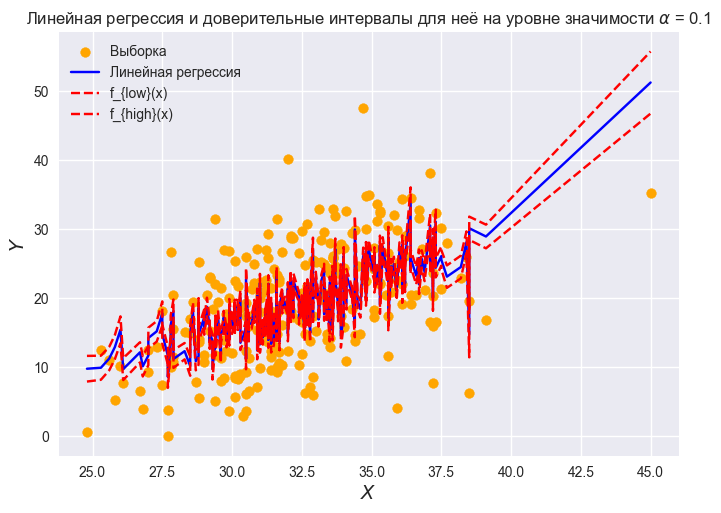

In [381]:
plt.scatter(X, Y, label="Выборка", color="orange")
plt.plot(
    table["x"],
    table["f(x)"],
    label="Линейная регрессия",
    color="blue",
)

plt.plot(
    table["x"], table["f_low(x)"], label=r"f_{low}(x)", color="red", linestyle="--"
)
plt.plot(
    table["x"], table["f_high(x)"], label=r"f_{high}(x)", color="red", linestyle="--"
)

plt.legend()
plt.xlabel("$X$", fontsize=14)
plt.ylabel("$Y$", fontsize=14)
plt.title(
    r"Линейная регрессия и доверительные интервалы для неё на уровне значимости $\alpha$ = 0.1"
)
plt.show()

#### Построить график остатков $\varepsilon(x) = y - f(x)$

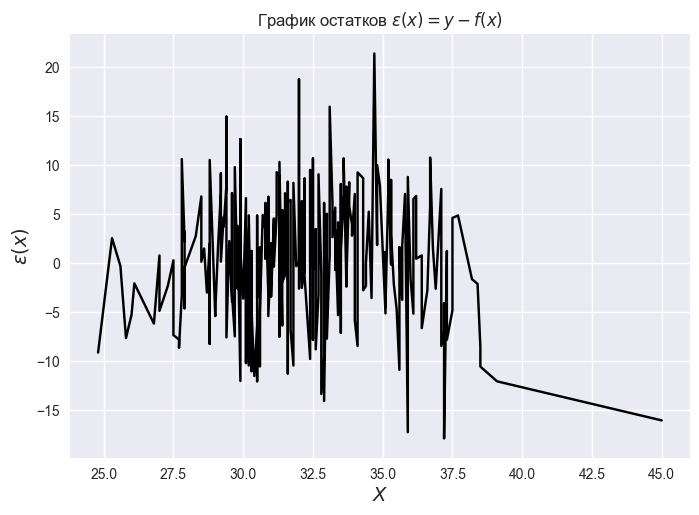

In [382]:
plt.plot(table["x"], table["y"] - table["f(x)"], color="black")
plt.xlabel("$X$", fontsize=14)
plt.ylabel(r"$\varepsilon(x)$", fontsize=14)
plt.title(r"График остатков $\varepsilon(x) = y - f(x)$")
plt.show()

### 9.2.3. Проверка значимости линейной регрессионной модели

Статистическая гипотеза $H_0:\ \beta_1 = \beta_2 = 0; \quad H':\ \beta_1^2 + \beta_2^2 > 0$.

#### Указать формулы расчёта показателей, используемых при проверке значимости линейной регрессионной модели

|                                                                                  | Выражение                                                               | Пояснение использованных обозначений                |
| -------------------------------------------------------------------------------- | ----------------------------------------------------------------------- | --------------------------------------------------- |
| Формула расчёта статистики критерия                                              | $Z = \dfrac{\tilde{D}_{Y \mid X}^{несмещ}}{\tilde{D}_{Y ост}^{несмещ}}$ | $n$ - объём выборки $(x_1, y_1), \dots, (x_n, y_n)$ |
| Закон распределения статистики критерия при условии истинности основной гипотезы | $F(k-1,\ n-2)$                                                          |                                                     |
| Формулы расчёта критической точки                                                | $F_{1 - \alpha,\ k-1,\ n-2}$                                            | Правосторонняя критическая область.                 |
| Формула расчёта $p$-value                                                        | $1 - F_Z(z_{\text{выб}} \mid H_0)$                                      |                                                     |

#### Проверить значимость линейной регрессионной модели

In [384]:
alphas = [0.01, 0.05, 0.1]

z = model.fvalue
p_value = model.f_pvalue

mprint(
    r"### Проверка значимости линейной регрессии",
    f"$H_0$: $\\beta_1 = \\beta_2 = 0$, $H_1$: $\\beta_1^2 + \\beta_2^2 > 0$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### Проверка значимости линейной регрессии

$H_0$: $\beta_1 = \beta_2 = 0$, $H_1$: $\beta_1^2 + \beta_2^2 > 0$

$z_{выб} =$ 74.72

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

<a id="93"></a>

## 9.3 Множественная линейная регрессионная модель

### Условие

Факторный признак 1 $x_1$ - `B16` Biceps circumference (cm)

Факторный признак 2 $x_2$ - `B7`  Weight (lbs)

Результативный признак $y$ - `B2` (Percent body fat from Siri's equation)

Уравнение регрессии - $f(x) = \beta_0 + \beta_1x_1 + \beta_2x_2$

### Определения

In [473]:
X1, X2, Y = data("9.3")
X1.head(), X2.head(), Y.head()

(0    32.0
 1    30.5
 2    28.8
 3    32.4
 4    32.2
 Name: B16, dtype: float64,
 0    154.25
 1    173.25
 2    154.00
 3    184.75
 4    184.25
 Name: B7, dtype: float64,
 0    12.3
 1     6.1
 2    25.3
 3    10.4
 4    28.7
 Name: B2, dtype: float64)

In [474]:
print(n1 := len(X1), n2 := len(X2), n3 := len(Y))

if n1 == n2 == n3:
    n = n1

252 252 252


In [475]:
k = 3

### Рассчитать точечные оценки параметров множественной линейной регрессионной модели

В данном случае $\varphi_0(x) = 1$, $\varphi_1(x) = x_1$, $\varphi_2(x) = x_2$.

`design matrix` точно такая же: $\begin{pmatrix}1 & x_{11} & x_{12} \\ 1 & x_{21} & x_{22} \\ \vdots & \vdots & \vdots \\ 1 & x_{n1} & x_{n2}\end{pmatrix}$.

In [476]:
vector_X = np.column_stack([X1, X2])
vector_X[:5]

array([[ 32.  , 154.25],
       [ 30.5 , 173.25],
       [ 28.8 , 154.  ],
       [ 32.4 , 184.75],
       [ 32.2 , 184.25]])

In [477]:
design_matrix = sm.add_constant(vector_X)
design_matrix[:5]

array([[  1.  ,  32.  , 154.25],
       [  1.  ,  30.5 , 173.25],
       [  1.  ,  28.8 , 154.  ],
       [  1.  ,  32.4 , 184.75],
       [  1.  ,  32.2 , 184.25]])

Построим МНК-оценки параметров $\beta_0, \beta_1, \beta_2$ по формуле $\tilde{\beta}_{\downarrow} = (F^T F)^{-1} F^T y_{\downarrow}$, где $F$ - `design matrix`, $y_{\downarrow}$ - вектор значений результативного признака.

In [478]:
model = sm.OLS(Y, design_matrix).fit()

mprint(
    f"$\\tilde{{\\beta_0}} =$ {model.params.iloc[0]:.2f}",
    f"$\\tilde{{\\beta_1}} =$ {model.params.iloc[1]:.2f}",
    f"$\\tilde{{\\beta_2}} =$ {model.params.iloc[2]:.2f}",
)

$\tilde{\beta_0} =$ -12.47

$\tilde{\beta_1} =$ 0.02

$\tilde{\beta_2} =$ 0.17

### Записать точечную оценку уравнения регрессии

In [479]:
predictions = model.predict(design_matrix)

In [480]:
D_YX = sum((predictions - Y.mean()) ** 2) / n
D_resY = sum((predictions - Y) ** 2) / n
D_Y = Y.var(ddof=0)

D_YX_unbiased = D_YX * n / (k - 1)
D_resY_unbiased = D_resY * n / (n - k)
D_Y_unbiased = D_Y * n / (n - 1)

mprint(
    f"$\\tilde{{D}}_{{Y \\mid X_1, X_2}} =$ {D_YX:.2f}",
    f"$\\tilde{{D}}_{{Y ост}} =$ {D_resY:.2f}",
    f"$\\tilde{{D}}_{{Y общ}} =$ {D_Y:.2f}",
    f"$\\tilde{{D}}_{{Y \\mid X_1, X_2, несмещ}} =$ {D_YX_unbiased:.2f}",
    f"$\\tilde{{D}}_{{Y ост, несмещ}} =$ {D_resY_unbiased:.2f}",
    f"$\\tilde{{D}}_{{Y общ, несмещ}} =$ {D_Y_unbiased:.2f}",
)

$\tilde{D}_{Y \mid X_1, X_2} =$ 26.16

$\tilde{D}_{Y ост} =$ 43.59

$\tilde{D}_{Y общ} =$ 69.76

$\tilde{D}_{Y \mid X_1, X_2, несмещ} =$ 3296.74

$\tilde{D}_{Y ост, несмещ} =$ 44.12

$\tilde{D}_{Y общ, несмещ} =$ 70.04

### Проверить правило сложения дисперсий

In [481]:
mprint(
    f"$\\tilde{{D}}_{{Y \\mid X_1, X_2}} =$ {D_YX:.2f}",
    f"$\\tilde{{D}}_{{Y ост}} =$ {D_resY:.2f}",
    f"$\\tilde{{D}}_{{Y общ}} =$ {D_Y:.2f}",
    f"$\\tilde{{D}}_{{Y \\mid X_1, X_2}} + \\tilde{{D}}_{{Y ост}} = {D_YX + D_resY:.2f}$",
)
print(D_YX + D_resY - D_Y < 1e-10)

$\tilde{D}_{Y \mid X_1, X_2} =$ 26.16

$\tilde{D}_{Y ост} =$ 43.59

$\tilde{D}_{Y общ} =$ 69.76

$\tilde{D}_{Y \mid X_1, X_2} + \tilde{D}_{Y ост} = 69.76$

True


| Показатель | $\tilde{D}_{Y \mid X_1, X_2}$ | $\tilde{D}_{Y\text{ ост}}$ | $\tilde{D}_{Y \text{ общ}}$ | $\tilde{D}_{Y \mid X_1, X_2} + \tilde{D}_{Y\text{ ост}}$ |
| ---------- | ----------------------------- | -------------------------- | --------------------------- | -------------------------------------------------------- |
| Значение   | 68.09                         | 1.67                       | 69.76                       | 69.76                                                    |


### Рассчитать показатели тесноты связи между факторными и результативным признаками

In [482]:
mprint(
    f"$\\tilde{{R^2}} =$ {model.rsquared:.2f}",
    f"$\\tilde{{R}} =$ {m.sqrt(model.rsquared):.2f}",
)

$\tilde{R^2} =$ 0.38

$\tilde{R} =$ 0.61

In [483]:
alphas = [0.01, 0.05, 0.1]

z = model.fvalue
p_value = model.f_pvalue

mprint(
    r"### Проверка значимости линейной регрессии",
    f"$H_0$: $\\beta_1 = \\beta_2 = \\beta_3 = 0$, $H_1$: $\\beta_1^2 + \\beta_2^2 + \\beta_3^2 > 0$",
    f"$z_{{выб}} =$ {z:.2f}",
    f"$p =$ {p_value:.2f}",
)

for alpha in alphas:
    mprint(f"При $\\alpha = {alpha}$ {verdict(alpha, p_value)}")

### Проверка значимости линейной регрессии

$H_0$: $\beta_1 = \beta_2 = \beta_3 = 0$, $H_1$: $\beta_1^2 + \beta_2^2 + \beta_3^2 > 0$

$z_{выб} =$ 74.72

$p =$ 0.00

При $\alpha = 0.01$ $H_0$ отклоняется

При $\alpha = 0.05$ $H_0$ отклоняется

При $\alpha = 0.1$ $H_0$ отклоняется

<a id="94"></a>